In [1]:
import random
import time
from datetime import datetime
import collections
import csv

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Network analysis
import networkx as nx

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,  roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, HeteroData
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,
    TransformerConv,
    GCNConv,
    MessagePassing
)
from collections import Counter, defaultdict

#optuna
import optuna

/home/rshrestha1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=10, dropout=0.1):
        super().__init__()
        self.gat1 = TransformerConv(in_channels, hidden_channels, heads=10, concat=False, dropout=dropout)
        self.gat2 = TransformerConv(hidden_channels, out_channels, heads=10, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

class NodeClassifier(nn.Module):
    def __init__(self, out_channels, num_classes):
        super().__init__()
        self.dropout = nn.Dropout(0.01)
        self.fc = nn.Linear(out_channels * 3 + 12, out_channels)
        self.fc1 = nn.Linear(out_channels, num_classes)

    def forward(self, x):
        x = self.fc(x)
        x = self.dropout(x)
        return self.fc1(x)

In [3]:
def train_model(encoder, classifier, data, optimizer, criterion, device):
    encoder.train()
    classifier.train()
    optimizer.zero_grad()
    data = data.to(device)

    x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
    
    y = data['company'].y
    train_mask = data['company'].train_mask

    x_dict = x_dict.to(device)
    edge_index_dict = edge_index_dict.to(device)
    y = y.to(device)

    node_repr = encoder(x_dict, edge_index_dict)
    logits = node_repr

    loss = criterion(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.softmax(logits[train_mask], dim=1)
        preds = logits[train_mask].argmax(dim=1)

        y_true = y[train_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[train_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def validate_model(encoder, classifier, data, criterion, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
        y = data['company'].y
        val_mask = data['company'].val_mask

        x_dict = x_dict.to(device)
        edge_index_dict = edge_index_dict.to(device)
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        
        logits = node_repr

        loss = criterion(logits[val_mask], y[val_mask])
        probs = torch.softmax(logits[val_mask], dim=1)
        preds = logits[val_mask].argmax(dim=1)

        y_true = y[val_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[val_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def test_model(encoder, classifier, data, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
        y = data['company'].y
        test_mask = data['company'].test_mask  # use test_mask if available

        x_dict = x_dict.to(device)
        edge_index_dict = edge_index_dict.to(device)
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        
        logits = node_repr

        probs = torch.softmax(logits[test_mask], dim=1)
        preds = logits[test_mask].argmax(dim=1)

        y_true = y[test_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[test_mask])) > 1 else 0.0

    return acc, f1

In [4]:
def train_test(encoder, classifier, data, optimizer, criterion, device, epochs=1000, patience=100):
    best_val_loss = float('inf')
    counter = 0
    best_encoder = None
    best_classifier = None
    best_train_acc = None
    best_f1 = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_model(encoder, classifier, data, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = validate_model(encoder, classifier, data, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03d}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_f1 = val_f1
            counter = 0
            best_encoder = encoder.state_dict()
            best_classifier = classifier.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    if best_encoder is not None and best_classifier is not None:
        encoder.load_state_dict(best_encoder)
        classifier.load_state_dict(best_classifier)

    return encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, best_train_acc, best_f1

In [5]:
def run_experiment(year, metric, hidden_channels=64, out_channels=32, num_heads=4,
                   lr=0.01, weight_decay=5e-4, epochs=1000, patience=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = torch.load(f'Dataset/heterographdata{year}1.pt', weights_only=False)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    # print(data['company'].x)
    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")
    
    encoder = GAT(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels
    ).to(device)

    classifier = NodeClassifier(
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(classifier.parameters()), 
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, _, best_train_acc, best_f1 = train_test(
        encoder, classifier, data, optimizer, criterion, device, epochs=epochs, patience=patience
    )

    test_acc, test_f1 = test_model(encoder, classifier, data, device)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'Graph_EncoderClassifier_training_{year}_{metric}.png')
    plt.show()

    return {
        'encoder': encoder,
        'classifier': classifier,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time': training_time,
        'epochs_run': len(train_losses),
        'best_train_acc': best_train_acc
    }


========== Run 1 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0861, Val Loss: 2.9908, Train Acc: 0.4142, Val Acc: 0.5602
Epoch: 020, Train Loss: 2.6638, Val Loss: 2.5781, Train Acc: 0.5302, Val Acc: 0.6165
Epoch: 030, Train Loss: 2.2434, Val Loss: 2.1685, Train Acc: 0.5479, Val Acc: 0.6203
Epoch: 040, Train Loss: 1.8068, Val Loss: 1.7449, Train Acc: 0.5673, Val Acc: 0.6165
Epoch: 050, Train Loss: 1.4083, Val Loss: 1.3559, Train Acc: 0.5633, Val Acc: 0.6278
Epoch: 060, Train Loss: 1.1151, Val Loss: 1.0698, Train Acc: 0.5624, Val Acc: 0.6353
Epoch: 070, Train Loss: 0.9338, Val Loss: 0.9011, Train Acc: 0.5834, Val Acc: 0.6579
Epoch: 080, Train Loss: 0.8369, Val Loss: 0.8127, Train Acc: 0.5923, Val Acc: 0.6391
Epoch: 090, Train Loss: 0.7846, Val Loss: 0.7676, Train Acc: 0.5890, Val Acc: 0.6466
Epoch: 100, Train Loss: 0.7520, Val Loss: 0.7438, Train Acc: 0.5882, Val Acc: 0.6579
Epoch: 110, Train Loss

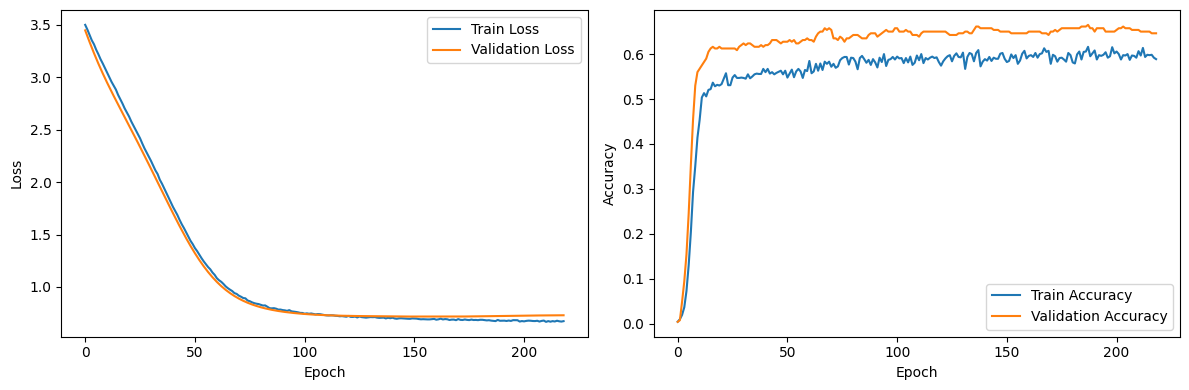


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0885, Val Loss: 3.0682, Train Acc: 0.4203, Val Acc: 0.4980
Epoch: 020, Train Loss: 2.6323, Val Loss: 2.6517, Train Acc: 0.4757, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.1989, Val Loss: 2.2241, Train Acc: 0.5017, Val Acc: 0.4863
Epoch: 040, Train Loss: 1.7745, Val Loss: 1.7918, Train Acc: 0.5134, Val Acc: 0.5059
Epoch: 050, Train Loss: 1.3900, Val Loss: 1.3981, Train Acc: 0.5285, Val Acc: 0.4863
Epoch: 060, Train Loss: 1.0973, Val Loss: 1.1051, Train Acc: 0.5604, Val Acc: 0.5098
Epoch: 070, Train Loss: 0.9251, Val Loss: 0.9305, Train Acc: 0.5529, Val Acc: 0.5098
Epoch: 080, Train Loss: 0.8334, Val Loss: 0.8379, Train Acc: 0.5461, Val Acc: 0.5137
Epoch: 090, Train Loss: 0.7803, Val Loss: 0.7886, Train Acc: 0.5562, Val Acc: 0.5176
Epoch: 100, Train Loss: 0.7469, Val Loss: 0.7602, Train Acc: 0.5797, Val Acc: 0.5294
Epoch: 110, Train Loss: 0.7342, Val Loss: 0.7422, Tr

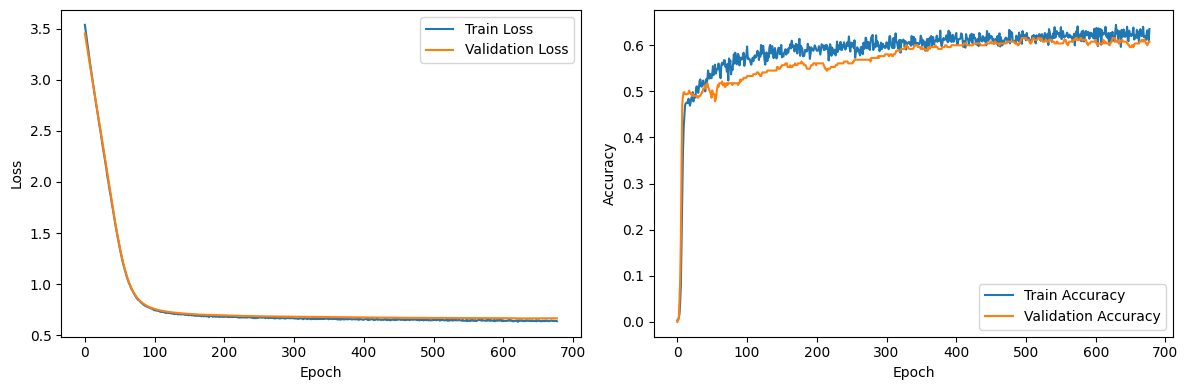


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0969, Val Loss: 3.0459, Train Acc: 0.4574, Val Acc: 0.4237
Epoch: 020, Train Loss: 2.7112, Val Loss: 2.6538, Train Acc: 0.5127, Val Acc: 0.4746
Epoch: 030, Train Loss: 2.3101, Val Loss: 2.2743, Train Acc: 0.5454, Val Acc: 0.4958
Epoch: 040, Train Loss: 1.8956, Val Loss: 1.8797, Train Acc: 0.5526, Val Acc: 0.4788
Epoch: 050, Train Loss: 1.5097, Val Loss: 1.5001, Train Acc: 0.5508, Val Acc: 0.4831
Epoch: 060, Train Loss: 1.1922, Val Loss: 1.1947, Train Acc: 0.5599, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.9864, Val Loss: 0.9950, Train Acc: 0.5626, Val Acc: 0.5127
Epoch: 080, Train Loss: 0.8682, Val Loss: 0.8832, Train Acc: 0.5608, Val Acc: 0.5169
Epoch: 090, Train Loss: 0.7988, Val Loss: 0.8229, Train Acc: 0.5835, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.7688, Val Loss: 0.7887, Train Acc: 0.5808, Val Acc: 0.5212
Epoch: 110, Train Loss: 0.7417, Val Loss: 0.7675, Tr

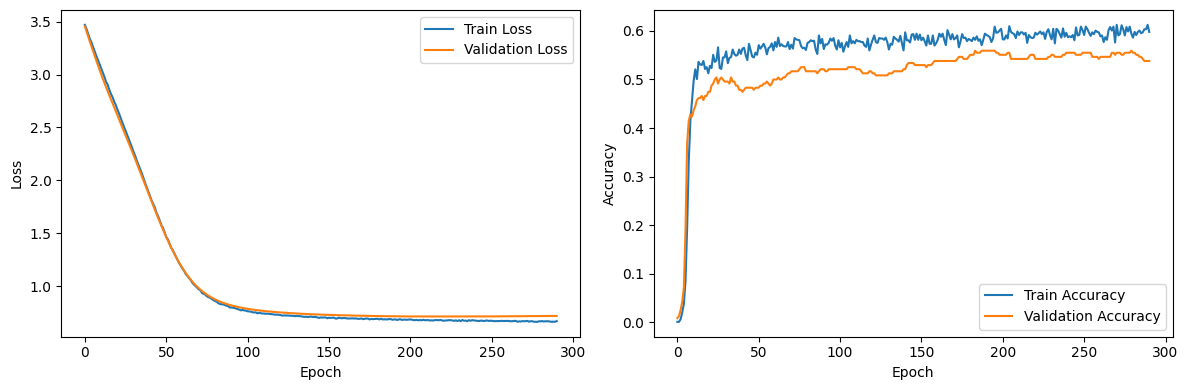


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2588, Val Loss: 3.1845, Train Acc: 0.1260, Val Acc: 0.1376
Epoch: 020, Train Loss: 2.8977, Val Loss: 2.8049, Train Acc: 0.4970, Val Acc: 0.4771
Epoch: 030, Train Loss: 2.5253, Val Loss: 2.4265, Train Acc: 0.5049, Val Acc: 0.4862
Epoch: 040, Train Loss: 2.1272, Val Loss: 2.0307, Train Acc: 0.5108, Val Acc: 0.4862
Epoch: 050, Train Loss: 1.7241, Val Loss: 1.6391, Train Acc: 0.5138, Val Acc: 0.4908
Epoch: 060, Train Loss: 1.3590, Val Loss: 1.3052, Train Acc: 0.5207, Val Acc: 0.5183
Epoch: 070, Train Loss: 1.0979, Val Loss: 1.0711, Train Acc: 0.5118, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.9413, Val Loss: 0.9319, Train Acc: 0.5285, Val Acc: 0.5138
Epoch: 090, Train Loss: 0.8557, Val Loss: 0.8543, Train Acc: 0.5394, Val Acc: 0.5138
Epoch: 100, Train Loss: 0.7970, Val Loss: 0.8090, Train Acc: 0.5669, Val Acc: 0.4954
Epoch: 110, Train Loss: 0.7665, Val Loss: 0.7811, Tr

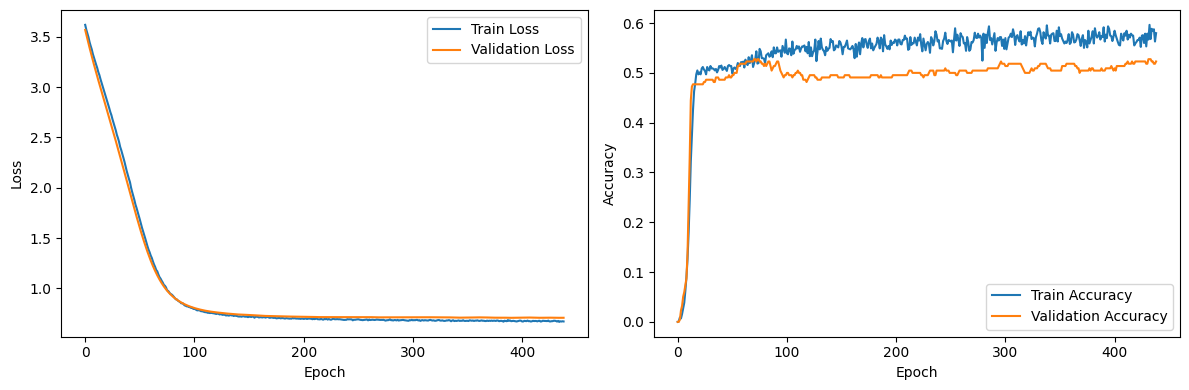


========== Run 2 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1932, Val Loss: 3.0976, Train Acc: 0.3602, Val Acc: 0.3947
Epoch: 020, Train Loss: 2.7900, Val Loss: 2.7003, Train Acc: 0.4786, Val Acc: 0.4699
Epoch: 030, Train Loss: 2.3963, Val Loss: 2.3166, Train Acc: 0.4956, Val Acc: 0.4925
Epoch: 040, Train Loss: 2.0035, Val Loss: 1.9264, Train Acc: 0.5036, Val Acc: 0.5113
Epoch: 050, Train Loss: 1.6218, Val Loss: 1.5474, Train Acc: 0.5052, Val Acc: 0.5075
Epoch: 060, Train Loss: 1.2766, Val Loss: 1.2246, Train Acc: 0.5165, Val Acc: 0.5226
Epoch: 070, Train Loss: 1.0343, Val Loss: 1.0007, Train Acc: 0.5391, Val Acc: 0.5414
Epoch: 080, Train Loss: 0.8929, Val Loss: 0.8743, Train Acc: 0.5705, Val Acc: 0.5865
Epoch: 090, Train Loss: 0.8136, Val Loss: 0.8108, Train Acc: 0.5673, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.7662, Val Loss: 0.7785, Train Acc: 0.5794, Val Acc: 0.6090
Epoch: 110, Train Loss

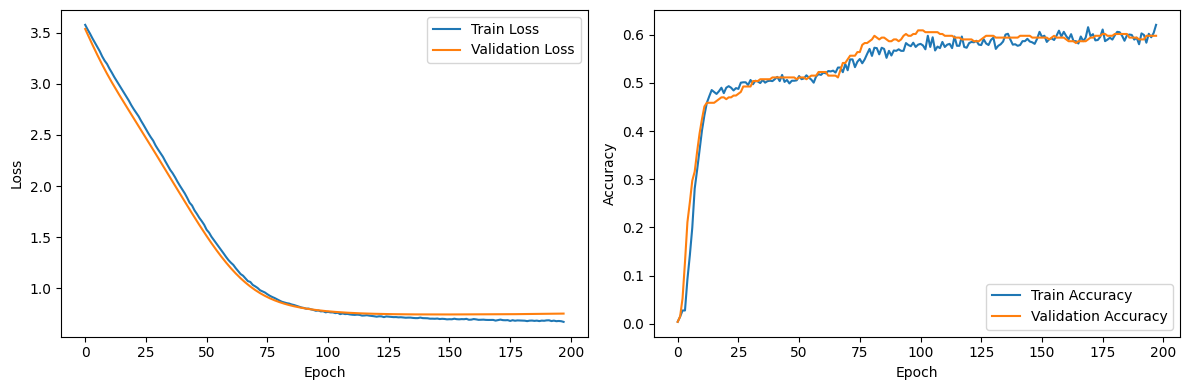


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0906, Val Loss: 3.0937, Train Acc: 0.4102, Val Acc: 0.4745
Epoch: 020, Train Loss: 2.7324, Val Loss: 2.7688, Train Acc: 0.5369, Val Acc: 0.5255
Epoch: 030, Train Loss: 2.3599, Val Loss: 2.4006, Train Acc: 0.5302, Val Acc: 0.5176
Epoch: 040, Train Loss: 1.9644, Val Loss: 1.9867, Train Acc: 0.5562, Val Acc: 0.4902
Epoch: 050, Train Loss: 1.5517, Val Loss: 1.5632, Train Acc: 0.5545, Val Acc: 0.4941
Epoch: 060, Train Loss: 1.2002, Val Loss: 1.2072, Train Acc: 0.5621, Val Acc: 0.5020
Epoch: 070, Train Loss: 0.9694, Val Loss: 0.9768, Train Acc: 0.5604, Val Acc: 0.5059
Epoch: 080, Train Loss: 0.8487, Val Loss: 0.8555, Train Acc: 0.5529, Val Acc: 0.4980
Epoch: 090, Train Loss: 0.7893, Val Loss: 0.7944, Train Acc: 0.5713, Val Acc: 0.5098
Epoch: 100, Train Loss: 0.7511, Val Loss: 0.7611, Train Acc: 0.5831, Val Acc: 0.5137
Epoch: 110, Train Loss: 0.7337, Val Loss: 0.7418, Tr

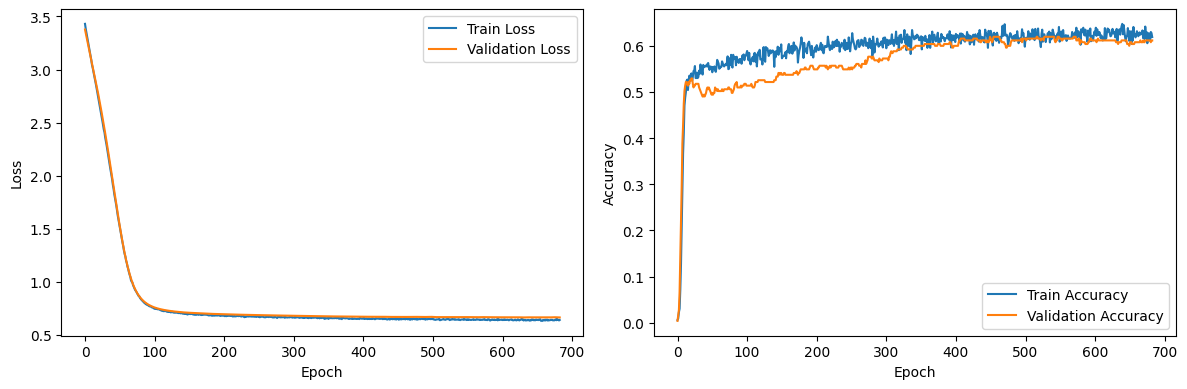


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1446, Val Loss: 3.0944, Train Acc: 0.4401, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.7634, Val Loss: 2.7199, Train Acc: 0.5508, Val Acc: 0.5212
Epoch: 030, Train Loss: 2.3556, Val Loss: 2.3300, Train Acc: 0.5572, Val Acc: 0.5085
Epoch: 040, Train Loss: 1.9403, Val Loss: 1.9191, Train Acc: 0.5708, Val Acc: 0.5254
Epoch: 050, Train Loss: 1.5195, Val Loss: 1.5242, Train Acc: 0.5635, Val Acc: 0.5339
Epoch: 060, Train Loss: 1.1930, Val Loss: 1.2073, Train Acc: 0.5690, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.9817, Val Loss: 1.0002, Train Acc: 0.5907, Val Acc: 0.5169
Epoch: 080, Train Loss: 0.8603, Val Loss: 0.8837, Train Acc: 0.5789, Val Acc: 0.5085
Epoch: 090, Train Loss: 0.7955, Val Loss: 0.8220, Train Acc: 0.5789, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.7582, Val Loss: 0.7884, Train Acc: 0.5817, Val Acc: 0.5169
Epoch: 110, Train Loss: 0.7386, Val Loss: 0.7682, Tr

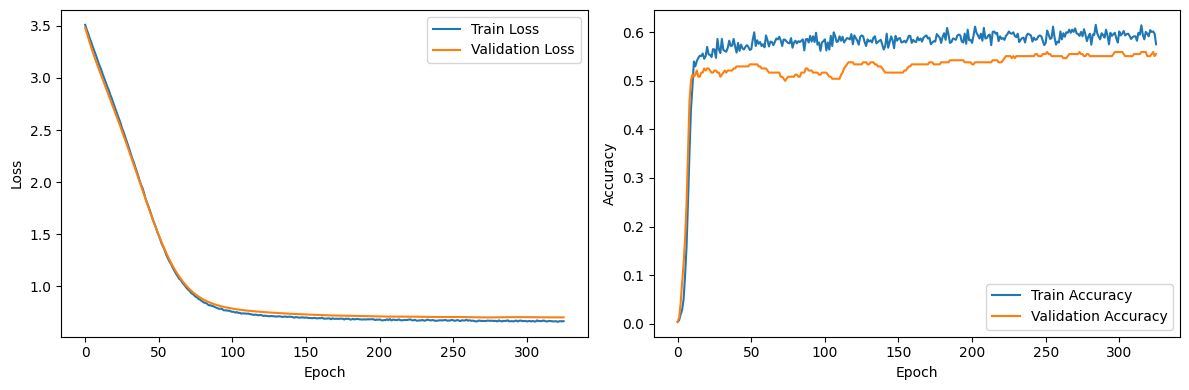


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1608, Val Loss: 3.0714, Train Acc: 0.3130, Val Acc: 0.4220
Epoch: 020, Train Loss: 2.7690, Val Loss: 2.6610, Train Acc: 0.5020, Val Acc: 0.4679
Epoch: 030, Train Loss: 2.3601, Val Loss: 2.2625, Train Acc: 0.5177, Val Acc: 0.4954
Epoch: 040, Train Loss: 1.9493, Val Loss: 1.8639, Train Acc: 0.5246, Val Acc: 0.5138
Epoch: 050, Train Loss: 1.5516, Val Loss: 1.4965, Train Acc: 0.5541, Val Acc: 0.5138
Epoch: 060, Train Loss: 1.2320, Val Loss: 1.2073, Train Acc: 0.5453, Val Acc: 0.4954
Epoch: 070, Train Loss: 1.0247, Val Loss: 1.0147, Train Acc: 0.5463, Val Acc: 0.4541
Epoch: 080, Train Loss: 0.9003, Val Loss: 0.9002, Train Acc: 0.5669, Val Acc: 0.4633
Epoch: 090, Train Loss: 0.8210, Val Loss: 0.8342, Train Acc: 0.5600, Val Acc: 0.4725
Epoch: 100, Train Loss: 0.7897, Val Loss: 0.7949, Train Acc: 0.5482, Val Acc: 0.4679
Epoch: 110, Train Loss: 0.7624, Val Loss: 0.7704, Tr

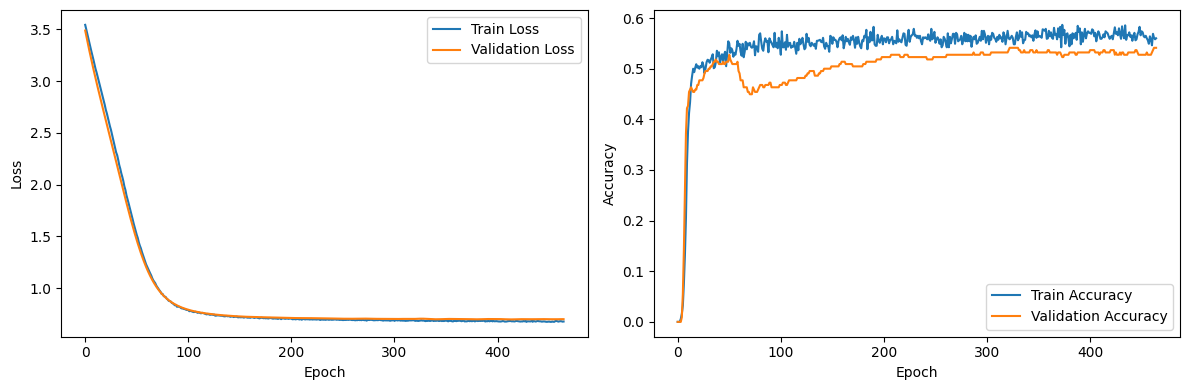


========== Run 3 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2546, Val Loss: 3.1661, Train Acc: 0.2514, Val Acc: 0.3609
Epoch: 020, Train Loss: 2.8497, Val Loss: 2.7649, Train Acc: 0.5060, Val Acc: 0.4962
Epoch: 030, Train Loss: 2.4577, Val Loss: 2.3913, Train Acc: 0.5205, Val Acc: 0.5113
Epoch: 040, Train Loss: 2.0503, Val Loss: 1.9966, Train Acc: 0.5230, Val Acc: 0.5075
Epoch: 050, Train Loss: 1.6411, Val Loss: 1.5988, Train Acc: 0.5254, Val Acc: 0.5038
Epoch: 060, Train Loss: 1.2884, Val Loss: 1.2523, Train Acc: 0.5407, Val Acc: 0.5075
Epoch: 070, Train Loss: 1.0339, Val Loss: 1.0093, Train Acc: 0.5624, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.8777, Val Loss: 0.8712, Train Acc: 0.5995, Val Acc: 0.6015
Epoch: 090, Train Loss: 0.7984, Val Loss: 0.8023, Train Acc: 0.5955, Val Acc: 0.6316
Epoch: 100, Train Loss: 0.7538, Val Loss: 0.7684, Train Acc: 0.6019, Val Acc: 0.6466
Epoch: 110, Train Loss

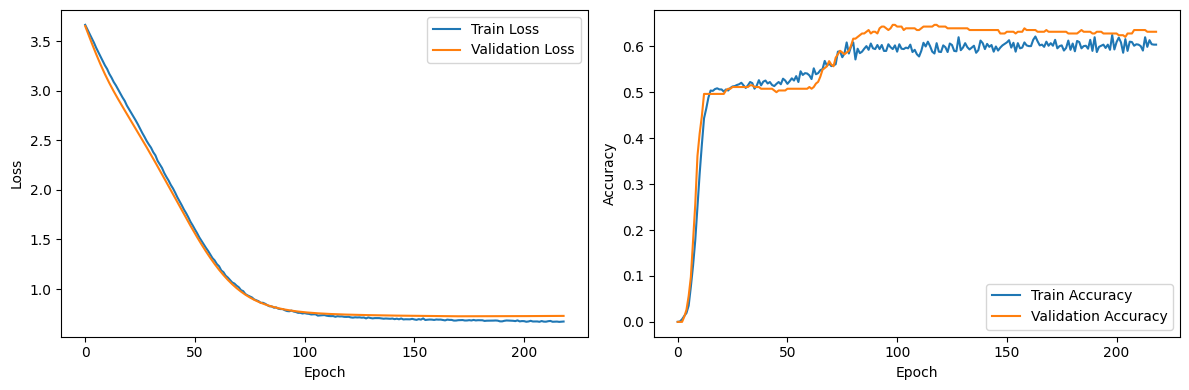


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0459, Val Loss: 3.0285, Train Acc: 0.4639, Val Acc: 0.5569
Epoch: 020, Train Loss: 2.6635, Val Loss: 2.6770, Train Acc: 0.5159, Val Acc: 0.5373
Epoch: 030, Train Loss: 2.2831, Val Loss: 2.3013, Train Acc: 0.5361, Val Acc: 0.5412
Epoch: 040, Train Loss: 1.8838, Val Loss: 1.9009, Train Acc: 0.5596, Val Acc: 0.5373
Epoch: 050, Train Loss: 1.5032, Val Loss: 1.5155, Train Acc: 0.5612, Val Acc: 0.5216
Epoch: 060, Train Loss: 1.1987, Val Loss: 1.2056, Train Acc: 0.5587, Val Acc: 0.5098
Epoch: 070, Train Loss: 0.9918, Val Loss: 1.0020, Train Acc: 0.5872, Val Acc: 0.5255
Epoch: 080, Train Loss: 0.8713, Val Loss: 0.8844, Train Acc: 0.5789, Val Acc: 0.5490
Epoch: 090, Train Loss: 0.8128, Val Loss: 0.8181, Train Acc: 0.5738, Val Acc: 0.5216
Epoch: 100, Train Loss: 0.7709, Val Loss: 0.7794, Train Acc: 0.5738, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.7474, Val Loss: 0.7552, Tr

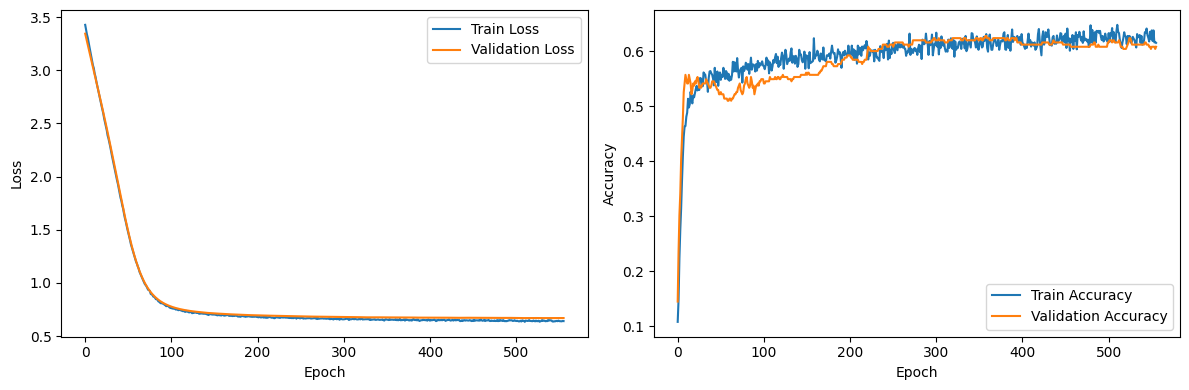


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0779, Val Loss: 3.0318, Train Acc: 0.4964, Val Acc: 0.4873
Epoch: 020, Train Loss: 2.7128, Val Loss: 2.6723, Train Acc: 0.5245, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.3339, Val Loss: 2.3045, Train Acc: 0.5272, Val Acc: 0.4746
Epoch: 040, Train Loss: 1.9350, Val Loss: 1.9205, Train Acc: 0.5327, Val Acc: 0.4661
Epoch: 050, Train Loss: 1.5579, Val Loss: 1.5492, Train Acc: 0.5417, Val Acc: 0.4788
Epoch: 060, Train Loss: 1.2311, Val Loss: 1.2418, Train Acc: 0.5653, Val Acc: 0.4873
Epoch: 070, Train Loss: 1.0192, Val Loss: 1.0318, Train Acc: 0.5572, Val Acc: 0.4873
Epoch: 080, Train Loss: 0.8994, Val Loss: 0.9073, Train Acc: 0.5817, Val Acc: 0.5085
Epoch: 090, Train Loss: 0.8187, Val Loss: 0.8358, Train Acc: 0.5880, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.7734, Val Loss: 0.7934, Train Acc: 0.6007, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.7559, Val Loss: 0.7669, Tr

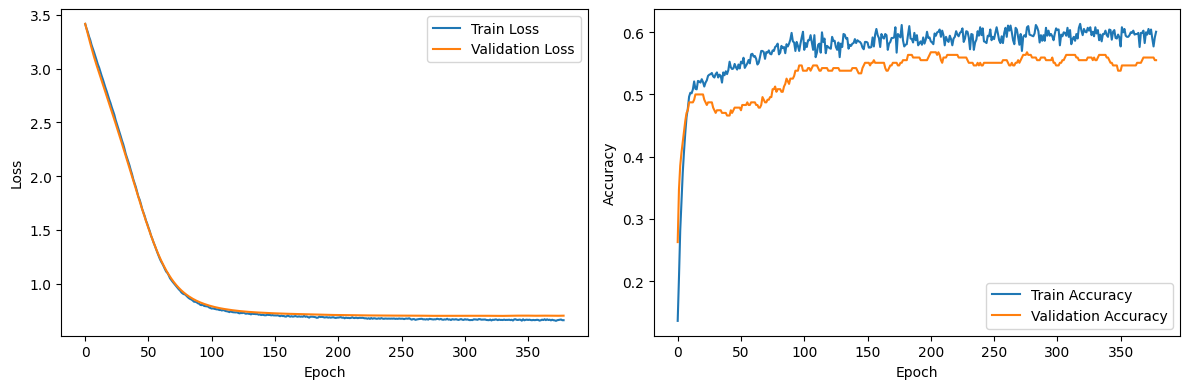


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0786, Val Loss: 2.9929, Train Acc: 0.4744, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.6595, Val Loss: 2.5491, Train Acc: 0.5069, Val Acc: 0.5046
Epoch: 030, Train Loss: 2.2378, Val Loss: 2.1398, Train Acc: 0.5256, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.8149, Val Loss: 1.7441, Train Acc: 0.5217, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.4289, Val Loss: 1.3934, Train Acc: 0.5167, Val Acc: 0.5092
Epoch: 060, Train Loss: 1.1441, Val Loss: 1.1327, Train Acc: 0.5167, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.9722, Val Loss: 0.9679, Train Acc: 0.5157, Val Acc: 0.4908
Epoch: 080, Train Loss: 0.8588, Val Loss: 0.8715, Train Acc: 0.5285, Val Acc: 0.4908
Epoch: 090, Train Loss: 0.8086, Val Loss: 0.8158, Train Acc: 0.5364, Val Acc: 0.4771
Epoch: 100, Train Loss: 0.7776, Val Loss: 0.7841, Train Acc: 0.5354, Val Acc: 0.4771
Epoch: 110, Train Loss: 0.7594, Val Loss: 0.7642, Tr

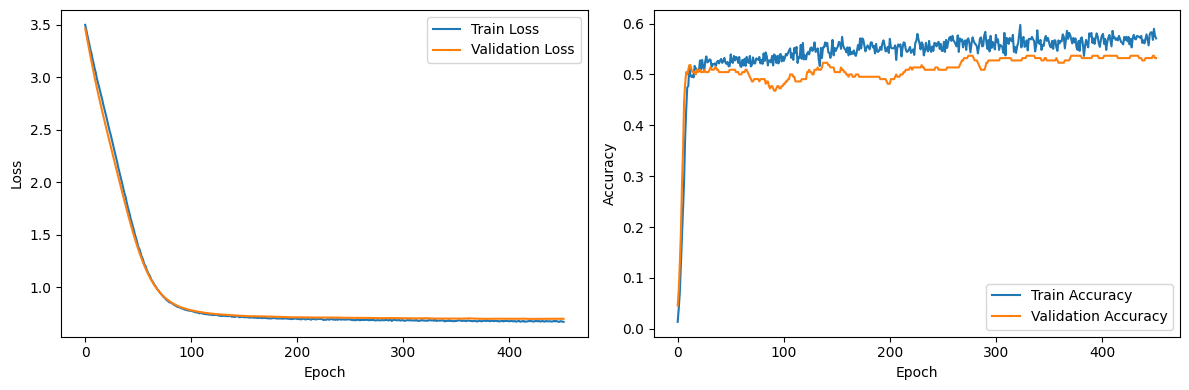


========== Run 4 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1741, Val Loss: 3.1243, Train Acc: 0.4158, Val Acc: 0.4624
Epoch: 020, Train Loss: 2.7918, Val Loss: 2.7123, Train Acc: 0.5302, Val Acc: 0.5226
Epoch: 030, Train Loss: 2.4003, Val Loss: 2.3221, Train Acc: 0.5455, Val Acc: 0.5263
Epoch: 040, Train Loss: 1.9822, Val Loss: 1.9163, Train Acc: 0.5697, Val Acc: 0.5489
Epoch: 050, Train Loss: 1.5728, Val Loss: 1.5205, Train Acc: 0.5713, Val Acc: 0.5602
Epoch: 060, Train Loss: 1.2368, Val Loss: 1.1957, Train Acc: 0.5915, Val Acc: 0.5677
Epoch: 070, Train Loss: 1.0037, Val Loss: 0.9843, Train Acc: 0.5898, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.8762, Val Loss: 0.8681, Train Acc: 0.5907, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.8056, Val Loss: 0.8072, Train Acc: 0.5979, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.7671, Val Loss: 0.7750, Train Acc: 0.5834, Val Acc: 0.5940
Epoch: 110, Train Loss

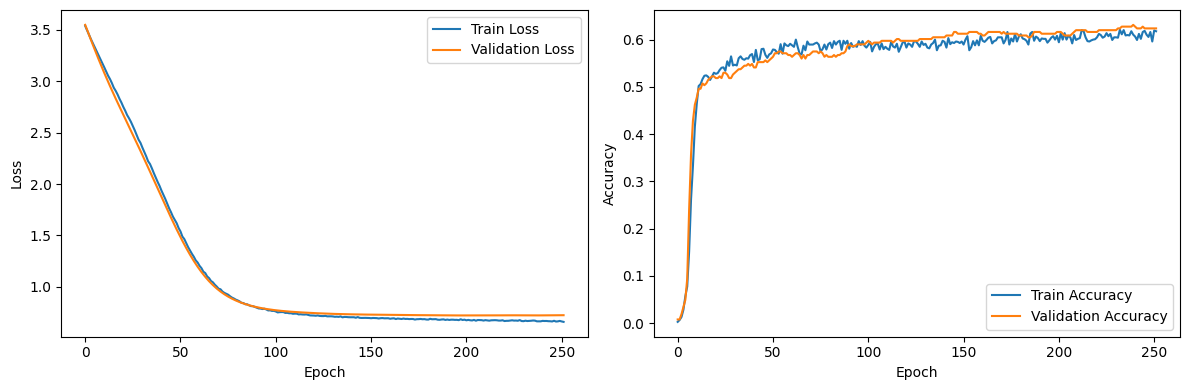


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0964, Val Loss: 3.0861, Train Acc: 0.4169, Val Acc: 0.4549
Epoch: 020, Train Loss: 2.6649, Val Loss: 2.6813, Train Acc: 0.4773, Val Acc: 0.4980
Epoch: 030, Train Loss: 2.2391, Val Loss: 2.2585, Train Acc: 0.4807, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.8094, Val Loss: 1.8234, Train Acc: 0.4950, Val Acc: 0.5137
Epoch: 050, Train Loss: 1.4287, Val Loss: 1.4270, Train Acc: 0.4908, Val Acc: 0.5176
Epoch: 060, Train Loss: 1.1325, Val Loss: 1.1313, Train Acc: 0.5008, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.9588, Val Loss: 0.9509, Train Acc: 0.5092, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.8552, Val Loss: 0.8517, Train Acc: 0.5227, Val Acc: 0.5294
Epoch: 090, Train Loss: 0.7942, Val Loss: 0.7968, Train Acc: 0.5419, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.7572, Val Loss: 0.7648, Train Acc: 0.5780, Val Acc: 0.5647
Epoch: 110, Train Loss: 0.7328, Val Loss: 0.7448, Tr

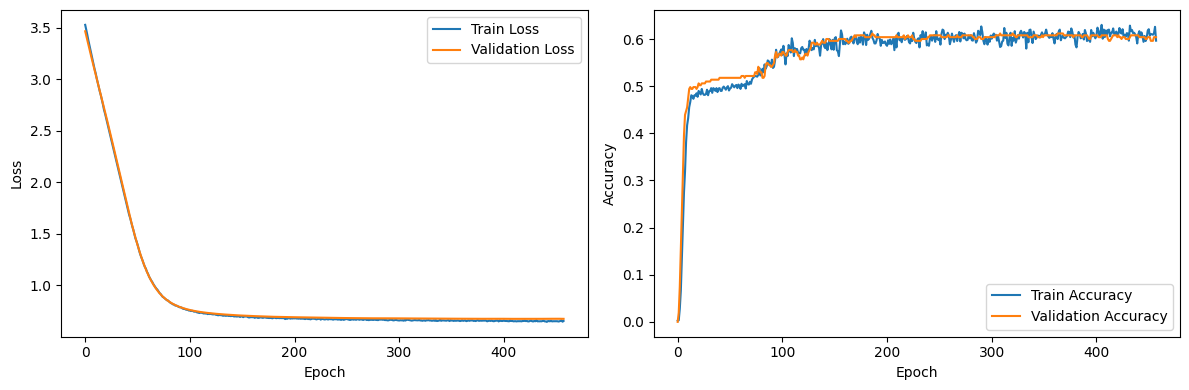


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2412, Val Loss: 3.1821, Train Acc: 0.1316, Val Acc: 0.2331
Epoch: 020, Train Loss: 2.8493, Val Loss: 2.7779, Train Acc: 0.4728, Val Acc: 0.5339
Epoch: 030, Train Loss: 2.4402, Val Loss: 2.3784, Train Acc: 0.4755, Val Acc: 0.5381
Epoch: 040, Train Loss: 2.0079, Val Loss: 1.9539, Train Acc: 0.4936, Val Acc: 0.5593
Epoch: 050, Train Loss: 1.5799, Val Loss: 1.5392, Train Acc: 0.5000, Val Acc: 0.5508
Epoch: 060, Train Loss: 1.2291, Val Loss: 1.2068, Train Acc: 0.4927, Val Acc: 0.5551
Epoch: 070, Train Loss: 1.0023, Val Loss: 0.9959, Train Acc: 0.5272, Val Acc: 0.5593
Epoch: 080, Train Loss: 0.8794, Val Loss: 0.8804, Train Acc: 0.5653, Val Acc: 0.5593
Epoch: 090, Train Loss: 0.8130, Val Loss: 0.8189, Train Acc: 0.5690, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.7742, Val Loss: 0.7851, Train Acc: 0.5789, Val Acc: 0.5297
Epoch: 110, Train Loss: 0.7463, Val Loss: 0.7655, Tr

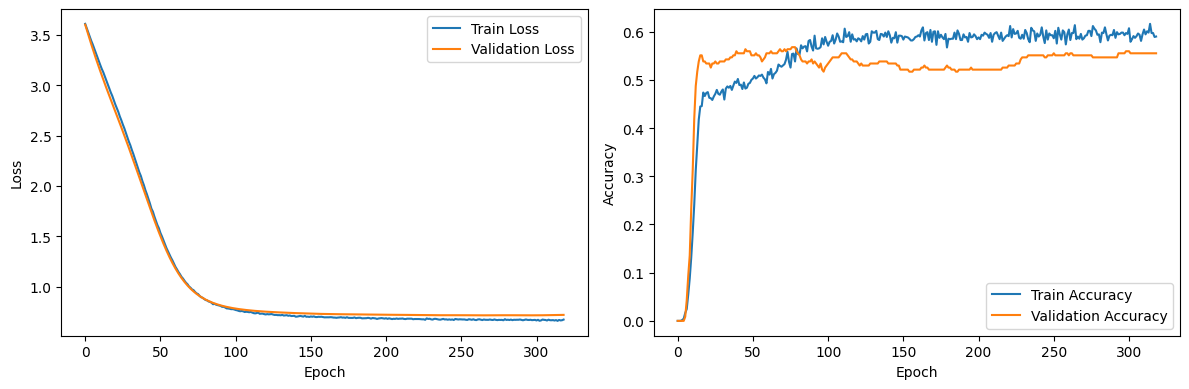


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1724, Val Loss: 3.1151, Train Acc: 0.3307, Val Acc: 0.3945
Epoch: 020, Train Loss: 2.7929, Val Loss: 2.7061, Train Acc: 0.4783, Val Acc: 0.4312
Epoch: 030, Train Loss: 2.3864, Val Loss: 2.2965, Train Acc: 0.4744, Val Acc: 0.4312
Epoch: 040, Train Loss: 1.9505, Val Loss: 1.8786, Train Acc: 0.4921, Val Acc: 0.4404
Epoch: 050, Train Loss: 1.5366, Val Loss: 1.4918, Train Acc: 0.4911, Val Acc: 0.4587
Epoch: 060, Train Loss: 1.2110, Val Loss: 1.1932, Train Acc: 0.5148, Val Acc: 0.4541
Epoch: 070, Train Loss: 0.9987, Val Loss: 1.0032, Train Acc: 0.5226, Val Acc: 0.4450
Epoch: 080, Train Loss: 0.8835, Val Loss: 0.8954, Train Acc: 0.5177, Val Acc: 0.4954
Epoch: 090, Train Loss: 0.8183, Val Loss: 0.8343, Train Acc: 0.5325, Val Acc: 0.4817
Epoch: 100, Train Loss: 0.7783, Val Loss: 0.7979, Train Acc: 0.5522, Val Acc: 0.4954
Epoch: 110, Train Loss: 0.7631, Val Loss: 0.7740, Tr

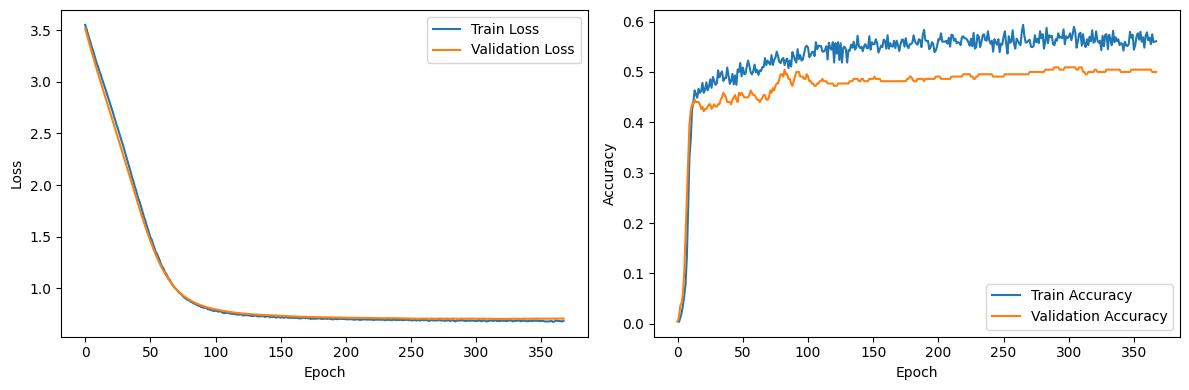


========== Run 5 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1800, Val Loss: 3.1026, Train Acc: 0.3691, Val Acc: 0.4474
Epoch: 020, Train Loss: 2.8354, Val Loss: 2.7518, Train Acc: 0.5334, Val Acc: 0.5338
Epoch: 030, Train Loss: 2.4678, Val Loss: 2.3969, Train Acc: 0.5568, Val Acc: 0.5639
Epoch: 040, Train Loss: 2.0675, Val Loss: 2.0047, Train Acc: 0.5697, Val Acc: 0.5752
Epoch: 050, Train Loss: 1.6596, Val Loss: 1.6032, Train Acc: 0.5874, Val Acc: 0.5940
Epoch: 060, Train Loss: 1.2949, Val Loss: 1.2553, Train Acc: 0.5802, Val Acc: 0.6015
Epoch: 070, Train Loss: 1.0482, Val Loss: 1.0170, Train Acc: 0.5955, Val Acc: 0.6128
Epoch: 080, Train Loss: 0.8923, Val Loss: 0.8827, Train Acc: 0.5987, Val Acc: 0.6165
Epoch: 090, Train Loss: 0.8126, Val Loss: 0.8130, Train Acc: 0.5907, Val Acc: 0.6241
Epoch: 100, Train Loss: 0.7714, Val Loss: 0.7760, Train Acc: 0.5842, Val Acc: 0.6203
Epoch: 110, Train Loss

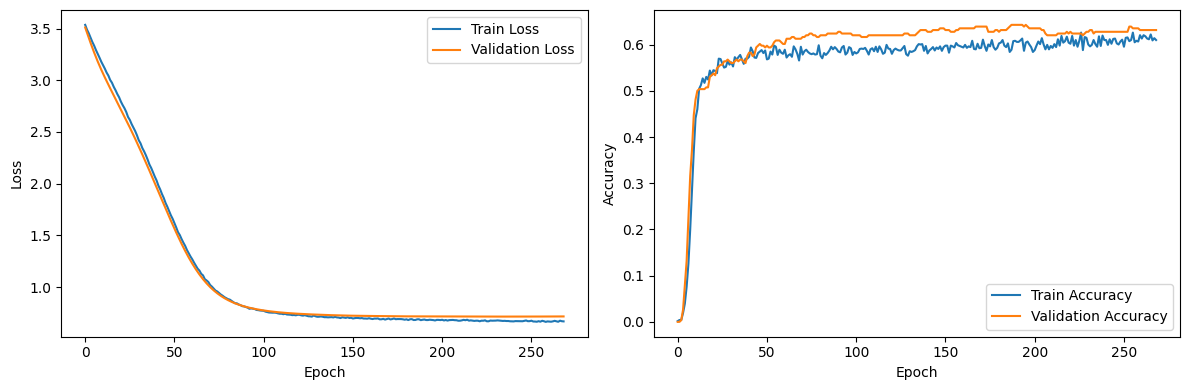


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0920, Val Loss: 3.0988, Train Acc: 0.4555, Val Acc: 0.4824
Epoch: 020, Train Loss: 2.6530, Val Loss: 2.6827, Train Acc: 0.5059, Val Acc: 0.4980
Epoch: 030, Train Loss: 2.2160, Val Loss: 2.2416, Train Acc: 0.5151, Val Acc: 0.4980
Epoch: 040, Train Loss: 1.7784, Val Loss: 1.7906, Train Acc: 0.5336, Val Acc: 0.4902
Epoch: 050, Train Loss: 1.3881, Val Loss: 1.3905, Train Acc: 0.5419, Val Acc: 0.4941
Epoch: 060, Train Loss: 1.1019, Val Loss: 1.1054, Train Acc: 0.5419, Val Acc: 0.4902
Epoch: 070, Train Loss: 0.9335, Val Loss: 0.9370, Train Acc: 0.5554, Val Acc: 0.5059
Epoch: 080, Train Loss: 0.8402, Val Loss: 0.8448, Train Acc: 0.5570, Val Acc: 0.5098
Epoch: 090, Train Loss: 0.7787, Val Loss: 0.7936, Train Acc: 0.5872, Val Acc: 0.5059
Epoch: 100, Train Loss: 0.7578, Val Loss: 0.7632, Train Acc: 0.5721, Val Acc: 0.5255
Epoch: 110, Train Loss: 0.7313, Val Loss: 0.7435, Tr

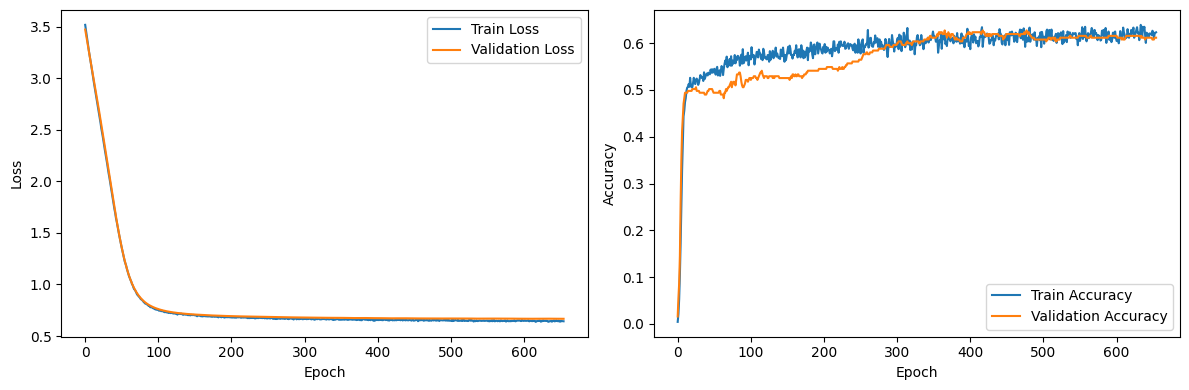


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2635, Val Loss: 3.2293, Train Acc: 0.1343, Val Acc: 0.1737
Epoch: 020, Train Loss: 2.9110, Val Loss: 2.8624, Train Acc: 0.5018, Val Acc: 0.4915
Epoch: 030, Train Loss: 2.5335, Val Loss: 2.4924, Train Acc: 0.5272, Val Acc: 0.4958
Epoch: 040, Train Loss: 2.1300, Val Loss: 2.0921, Train Acc: 0.5445, Val Acc: 0.5127
Epoch: 050, Train Loss: 1.7141, Val Loss: 1.6832, Train Acc: 0.5327, Val Acc: 0.5297
Epoch: 060, Train Loss: 1.3373, Val Loss: 1.3174, Train Acc: 0.5472, Val Acc: 0.5508
Epoch: 070, Train Loss: 1.0613, Val Loss: 1.0540, Train Acc: 0.5608, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.9025, Val Loss: 0.9024, Train Acc: 0.5744, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.8123, Val Loss: 0.8249, Train Acc: 0.5935, Val Acc: 0.5339
Epoch: 100, Train Loss: 0.7707, Val Loss: 0.7849, Train Acc: 0.5971, Val Acc: 0.5424
Epoch: 110, Train Loss: 0.7448, Val Loss: 0.7632, Tr

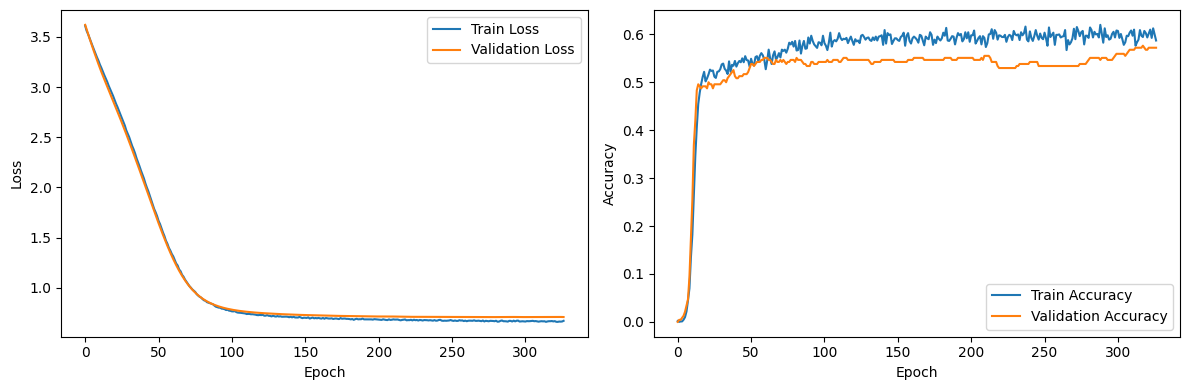


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2478, Val Loss: 3.1669, Train Acc: 0.2313, Val Acc: 0.2844
Epoch: 020, Train Loss: 2.8738, Val Loss: 2.7822, Train Acc: 0.5226, Val Acc: 0.4862
Epoch: 030, Train Loss: 2.4854, Val Loss: 2.3995, Train Acc: 0.5187, Val Acc: 0.4954
Epoch: 040, Train Loss: 2.0523, Val Loss: 1.9976, Train Acc: 0.5344, Val Acc: 0.4908
Epoch: 050, Train Loss: 1.6359, Val Loss: 1.6019, Train Acc: 0.5256, Val Acc: 0.5046
Epoch: 060, Train Loss: 1.2763, Val Loss: 1.2722, Train Acc: 0.5404, Val Acc: 0.5046
Epoch: 070, Train Loss: 1.0274, Val Loss: 1.0485, Train Acc: 0.5423, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.9056, Val Loss: 0.9165, Train Acc: 0.5374, Val Acc: 0.5046
Epoch: 090, Train Loss: 0.8222, Val Loss: 0.8413, Train Acc: 0.5591, Val Acc: 0.4862
Epoch: 100, Train Loss: 0.7803, Val Loss: 0.7973, Train Acc: 0.5650, Val Acc: 0.5000
Epoch: 110, Train Loss: 0.7583, Val Loss: 0.7707, Tr

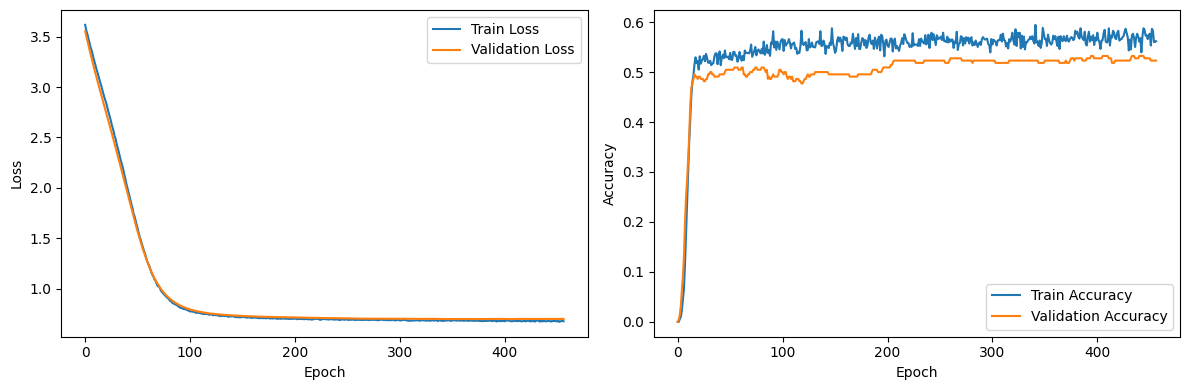


========== Run 6 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0337, Val Loss: 2.9486, Train Acc: 0.4867, Val Acc: 0.5038
Epoch: 020, Train Loss: 2.6414, Val Loss: 2.5511, Train Acc: 0.5020, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.2288, Val Loss: 2.1449, Train Acc: 0.5068, Val Acc: 0.5038
Epoch: 040, Train Loss: 1.8137, Val Loss: 1.7328, Train Acc: 0.5117, Val Acc: 0.5075
Epoch: 050, Train Loss: 1.4277, Val Loss: 1.3608, Train Acc: 0.5367, Val Acc: 0.5113
Epoch: 060, Train Loss: 1.1371, Val Loss: 1.0838, Train Acc: 0.5407, Val Acc: 0.5376
Epoch: 070, Train Loss: 0.9519, Val Loss: 0.9173, Train Acc: 0.5560, Val Acc: 0.5564
Epoch: 080, Train Loss: 0.8519, Val Loss: 0.8296, Train Acc: 0.5576, Val Acc: 0.5902
Epoch: 090, Train Loss: 0.7894, Val Loss: 0.7836, Train Acc: 0.5681, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.7548, Val Loss: 0.7575, Train Acc: 0.5866, Val Acc: 0.6128
Epoch: 110, Train Loss

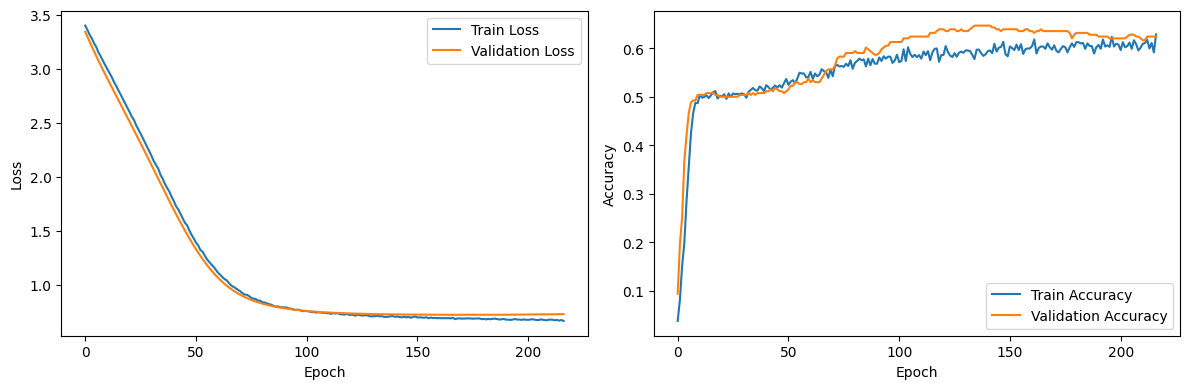


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8638, Val Loss: 2.8591, Train Acc: 0.5076, Val Acc: 0.5137
Epoch: 020, Train Loss: 2.4688, Val Loss: 2.4814, Train Acc: 0.5126, Val Acc: 0.5176
Epoch: 030, Train Loss: 2.0589, Val Loss: 2.0733, Train Acc: 0.5277, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.6557, Val Loss: 1.6576, Train Acc: 0.5344, Val Acc: 0.5216
Epoch: 050, Train Loss: 1.2940, Val Loss: 1.2963, Train Acc: 0.5260, Val Acc: 0.5412
Epoch: 060, Train Loss: 1.0425, Val Loss: 1.0443, Train Acc: 0.5495, Val Acc: 0.5373
Epoch: 070, Train Loss: 0.8958, Val Loss: 0.8970, Train Acc: 0.5495, Val Acc: 0.5294
Epoch: 080, Train Loss: 0.8165, Val Loss: 0.8163, Train Acc: 0.5688, Val Acc: 0.5412
Epoch: 090, Train Loss: 0.7626, Val Loss: 0.7712, Train Acc: 0.6141, Val Acc: 0.5686
Epoch: 100, Train Loss: 0.7395, Val Loss: 0.7446, Train Acc: 0.6074, Val Acc: 0.5686
Epoch: 110, Train Loss: 0.7267, Val Loss: 0.7278, Tr

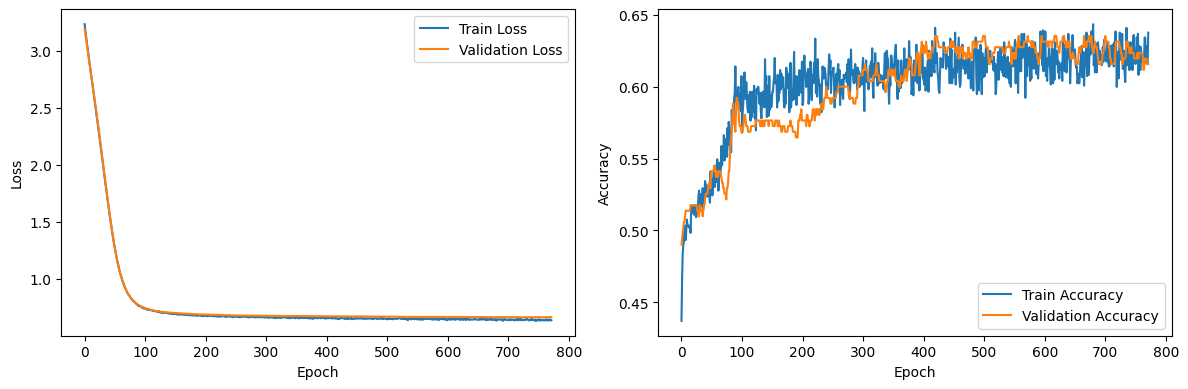


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1805, Val Loss: 3.1929, Train Acc: 0.4864, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.8019, Val Loss: 2.7846, Train Acc: 0.4982, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.3926, Val Loss: 2.3595, Train Acc: 0.5009, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.9615, Val Loss: 1.9168, Train Acc: 0.5054, Val Acc: 0.5042
Epoch: 050, Train Loss: 1.5430, Val Loss: 1.4977, Train Acc: 0.5036, Val Acc: 0.5085
Epoch: 060, Train Loss: 1.2121, Val Loss: 1.1664, Train Acc: 0.5000, Val Acc: 0.5085
Epoch: 070, Train Loss: 0.9929, Val Loss: 0.9562, Train Acc: 0.5054, Val Acc: 0.5212
Epoch: 080, Train Loss: 0.8643, Val Loss: 0.8439, Train Acc: 0.5399, Val Acc: 0.5212
Epoch: 090, Train Loss: 0.7977, Val Loss: 0.7901, Train Acc: 0.5808, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.7631, Val Loss: 0.7647, Train Acc: 0.5844, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.7335, Val Loss: 0.7511, Tr

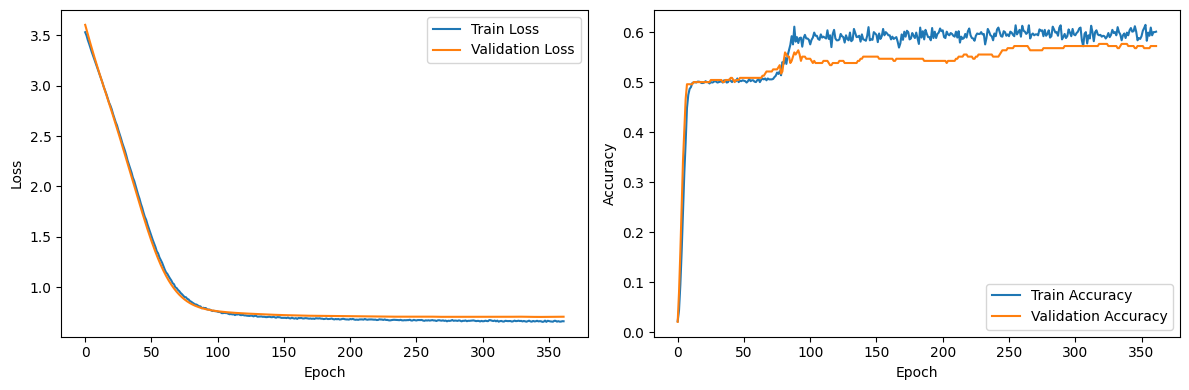


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0333, Val Loss: 2.9823, Train Acc: 0.5197, Val Acc: 0.5229
Epoch: 020, Train Loss: 2.6504, Val Loss: 2.5727, Train Acc: 0.5315, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.2496, Val Loss: 2.1744, Train Acc: 0.5541, Val Acc: 0.4908
Epoch: 040, Train Loss: 1.8455, Val Loss: 1.7844, Train Acc: 0.5541, Val Acc: 0.4817
Epoch: 050, Train Loss: 1.4687, Val Loss: 1.4328, Train Acc: 0.5669, Val Acc: 0.4771
Epoch: 060, Train Loss: 1.1832, Val Loss: 1.1634, Train Acc: 0.5531, Val Acc: 0.4862
Epoch: 070, Train Loss: 0.9823, Val Loss: 0.9882, Train Acc: 0.5453, Val Acc: 0.4817
Epoch: 080, Train Loss: 0.8741, Val Loss: 0.8842, Train Acc: 0.5620, Val Acc: 0.4771
Epoch: 090, Train Loss: 0.8142, Val Loss: 0.8236, Train Acc: 0.5640, Val Acc: 0.4679
Epoch: 100, Train Loss: 0.7822, Val Loss: 0.7878, Train Acc: 0.5659, Val Acc: 0.4587
Epoch: 110, Train Loss: 0.7614, Val Loss: 0.7661, Tr

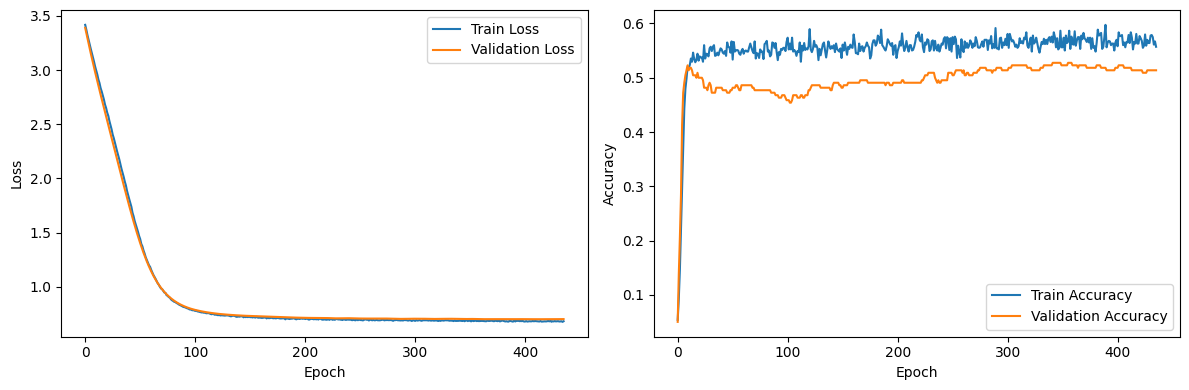


========== Run 7 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0798, Val Loss: 2.9894, Train Acc: 0.3280, Val Acc: 0.4211
Epoch: 020, Train Loss: 2.6963, Val Loss: 2.6143, Train Acc: 0.4786, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.2955, Val Loss: 2.2343, Train Acc: 0.5060, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.8803, Val Loss: 1.8346, Train Acc: 0.4923, Val Acc: 0.4962
Epoch: 050, Train Loss: 1.4885, Val Loss: 1.4551, Train Acc: 0.4932, Val Acc: 0.5038
Epoch: 060, Train Loss: 1.1683, Val Loss: 1.1594, Train Acc: 0.5197, Val Acc: 0.4850
Epoch: 070, Train Loss: 0.9712, Val Loss: 0.9763, Train Acc: 0.5576, Val Acc: 0.5338
Epoch: 080, Train Loss: 0.8508, Val Loss: 0.8781, Train Acc: 0.5520, Val Acc: 0.5564
Epoch: 090, Train Loss: 0.7898, Val Loss: 0.8262, Train Acc: 0.5786, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.7599, Val Loss: 0.7975, Train Acc: 0.5681, Val Acc: 0.6053
Epoch: 110, Train Loss

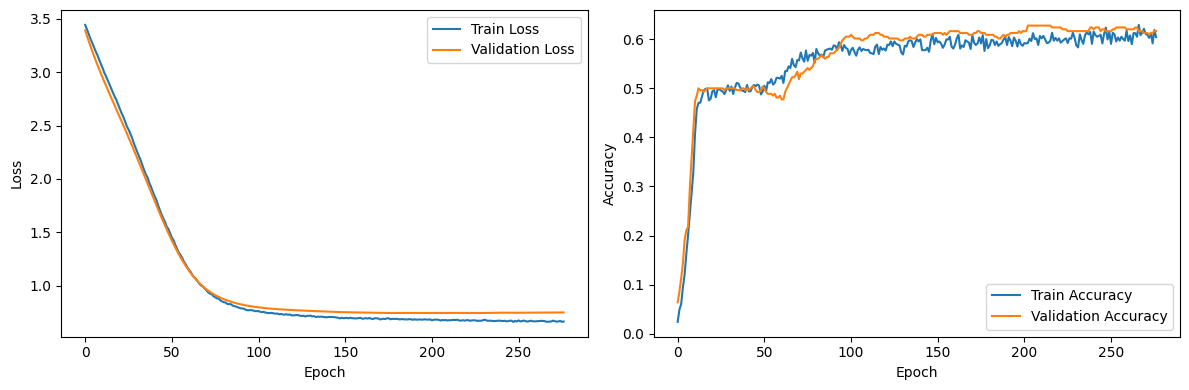


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1196, Val Loss: 3.1168, Train Acc: 0.4564, Val Acc: 0.4902
Epoch: 020, Train Loss: 2.7114, Val Loss: 2.7376, Train Acc: 0.5478, Val Acc: 0.4902
Epoch: 030, Train Loss: 2.3124, Val Loss: 2.3377, Train Acc: 0.5570, Val Acc: 0.4980
Epoch: 040, Train Loss: 1.8986, Val Loss: 1.9112, Train Acc: 0.5310, Val Acc: 0.5137
Epoch: 050, Train Loss: 1.4938, Val Loss: 1.4996, Train Acc: 0.5705, Val Acc: 0.5137
Epoch: 060, Train Loss: 1.1741, Val Loss: 1.1735, Train Acc: 0.5545, Val Acc: 0.5333
Epoch: 070, Train Loss: 0.9723, Val Loss: 0.9679, Train Acc: 0.5579, Val Acc: 0.5294
Epoch: 080, Train Loss: 0.8553, Val Loss: 0.8552, Train Acc: 0.5671, Val Acc: 0.5098
Epoch: 090, Train Loss: 0.7912, Val Loss: 0.7944, Train Acc: 0.5847, Val Acc: 0.5216
Epoch: 100, Train Loss: 0.7612, Val Loss: 0.7600, Train Acc: 0.5587, Val Acc: 0.5176
Epoch: 110, Train Loss: 0.7376, Val Loss: 0.7396, Tr

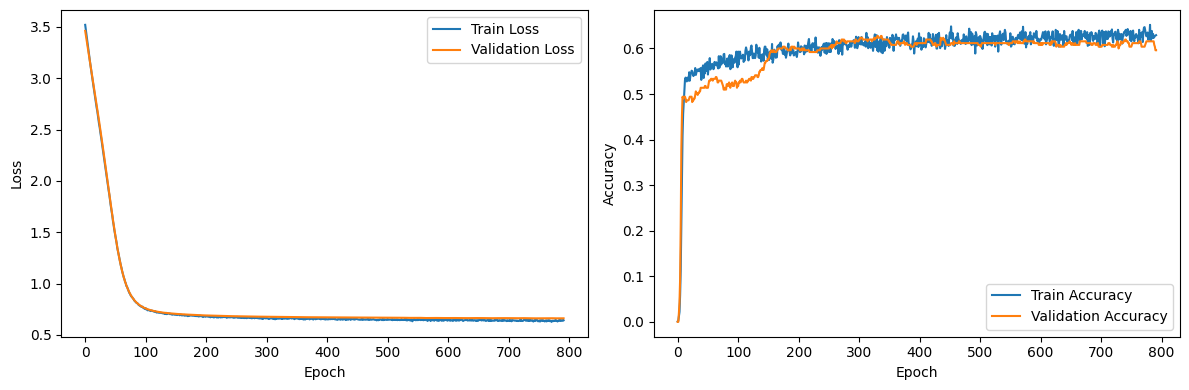


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1350, Val Loss: 3.0598, Train Acc: 0.4592, Val Acc: 0.4831
Epoch: 020, Train Loss: 2.7073, Val Loss: 2.6420, Train Acc: 0.5172, Val Acc: 0.4873
Epoch: 030, Train Loss: 2.2614, Val Loss: 2.2081, Train Acc: 0.5136, Val Acc: 0.4661
Epoch: 040, Train Loss: 1.8032, Val Loss: 1.7640, Train Acc: 0.5163, Val Acc: 0.4576
Epoch: 050, Train Loss: 1.3950, Val Loss: 1.3674, Train Acc: 0.5336, Val Acc: 0.4576
Epoch: 060, Train Loss: 1.1023, Val Loss: 1.0857, Train Acc: 0.5454, Val Acc: 0.4703
Epoch: 070, Train Loss: 0.9242, Val Loss: 0.9240, Train Acc: 0.5590, Val Acc: 0.4746
Epoch: 080, Train Loss: 0.8300, Val Loss: 0.8402, Train Acc: 0.5681, Val Acc: 0.4915
Epoch: 090, Train Loss: 0.7854, Val Loss: 0.7963, Train Acc: 0.5780, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.7548, Val Loss: 0.7717, Train Acc: 0.5735, Val Acc: 0.5297
Epoch: 110, Train Loss: 0.7356, Val Loss: 0.7567, Tr

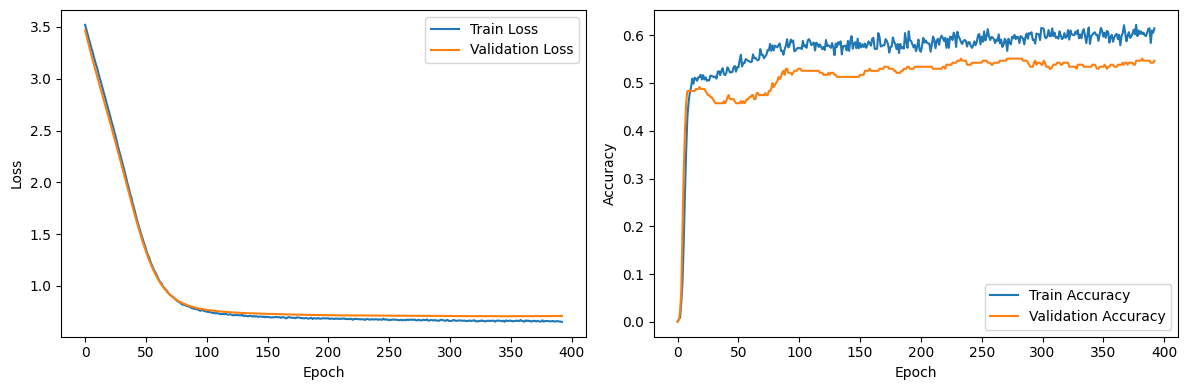


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9678, Val Loss: 2.9093, Train Acc: 0.5098, Val Acc: 0.4954
Epoch: 020, Train Loss: 2.5615, Val Loss: 2.4900, Train Acc: 0.5423, Val Acc: 0.5092
Epoch: 030, Train Loss: 2.1574, Val Loss: 2.0909, Train Acc: 0.5335, Val Acc: 0.4908
Epoch: 040, Train Loss: 1.7648, Val Loss: 1.7100, Train Acc: 0.5364, Val Acc: 0.4633
Epoch: 050, Train Loss: 1.4187, Val Loss: 1.3787, Train Acc: 0.5305, Val Acc: 0.4908
Epoch: 060, Train Loss: 1.1435, Val Loss: 1.1306, Train Acc: 0.5335, Val Acc: 0.4908
Epoch: 070, Train Loss: 0.9792, Val Loss: 0.9701, Train Acc: 0.5472, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.8718, Val Loss: 0.8749, Train Acc: 0.5610, Val Acc: 0.5000
Epoch: 090, Train Loss: 0.8147, Val Loss: 0.8197, Train Acc: 0.5453, Val Acc: 0.5046
Epoch: 100, Train Loss: 0.7819, Val Loss: 0.7878, Train Acc: 0.5423, Val Acc: 0.4954
Epoch: 110, Train Loss: 0.7568, Val Loss: 0.7669, Tr

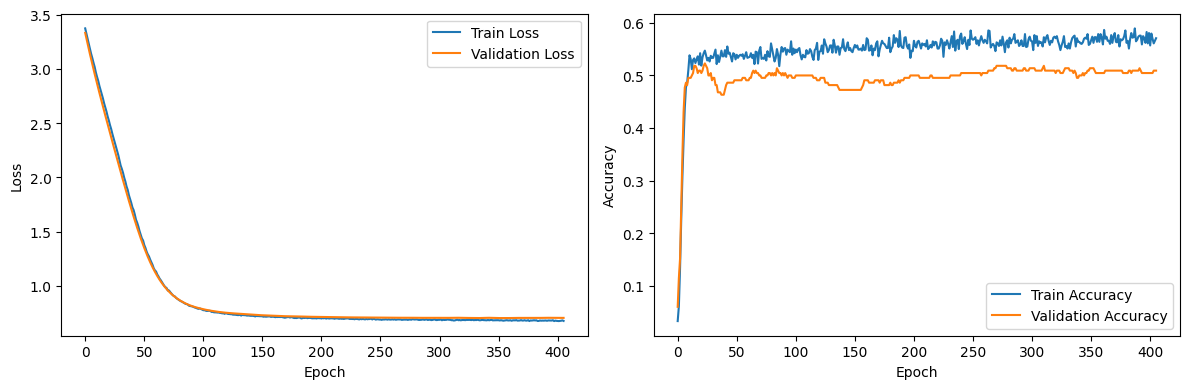


========== Run 8 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1379, Val Loss: 3.0859, Train Acc: 0.4529, Val Acc: 0.4812
Epoch: 020, Train Loss: 2.7798, Val Loss: 2.6946, Train Acc: 0.5060, Val Acc: 0.5075
Epoch: 030, Train Loss: 2.4034, Val Loss: 2.3256, Train Acc: 0.5254, Val Acc: 0.5075
Epoch: 040, Train Loss: 2.0135, Val Loss: 1.9431, Train Acc: 0.5375, Val Acc: 0.5188
Epoch: 050, Train Loss: 1.6345, Val Loss: 1.5679, Train Acc: 0.5391, Val Acc: 0.5376
Epoch: 060, Train Loss: 1.3031, Val Loss: 1.2480, Train Acc: 0.5488, Val Acc: 0.5489
Epoch: 070, Train Loss: 1.0549, Val Loss: 1.0221, Train Acc: 0.5616, Val Acc: 0.5451
Epoch: 080, Train Loss: 0.9123, Val Loss: 0.8890, Train Acc: 0.5705, Val Acc: 0.5376
Epoch: 090, Train Loss: 0.8307, Val Loss: 0.8174, Train Acc: 0.5673, Val Acc: 0.5376
Epoch: 100, Train Loss: 0.7854, Val Loss: 0.7783, Train Acc: 0.5729, Val Acc: 0.5451
Epoch: 110, Train Loss

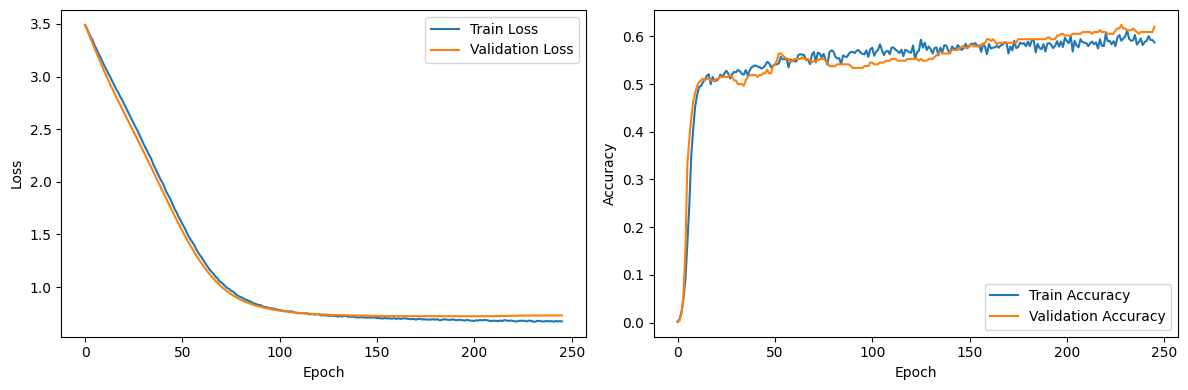


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0633, Val Loss: 3.0585, Train Acc: 0.4639, Val Acc: 0.4863
Epoch: 020, Train Loss: 2.7021, Val Loss: 2.7352, Train Acc: 0.5084, Val Acc: 0.4863
Epoch: 030, Train Loss: 2.3543, Val Loss: 2.3936, Train Acc: 0.5260, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.9940, Val Loss: 2.0227, Train Acc: 0.4950, Val Acc: 0.5137
Epoch: 050, Train Loss: 1.6271, Val Loss: 1.6437, Train Acc: 0.5285, Val Acc: 0.4902
Epoch: 060, Train Loss: 1.2971, Val Loss: 1.3044, Train Acc: 0.5252, Val Acc: 0.5137
Epoch: 070, Train Loss: 1.0574, Val Loss: 1.0537, Train Acc: 0.5185, Val Acc: 0.5529
Epoch: 080, Train Loss: 0.9064, Val Loss: 0.9016, Train Acc: 0.5344, Val Acc: 0.5373
Epoch: 090, Train Loss: 0.8196, Val Loss: 0.8192, Train Acc: 0.5730, Val Acc: 0.5647
Epoch: 100, Train Loss: 0.7732, Val Loss: 0.7741, Train Acc: 0.5478, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.7480, Val Loss: 0.7481, Tr

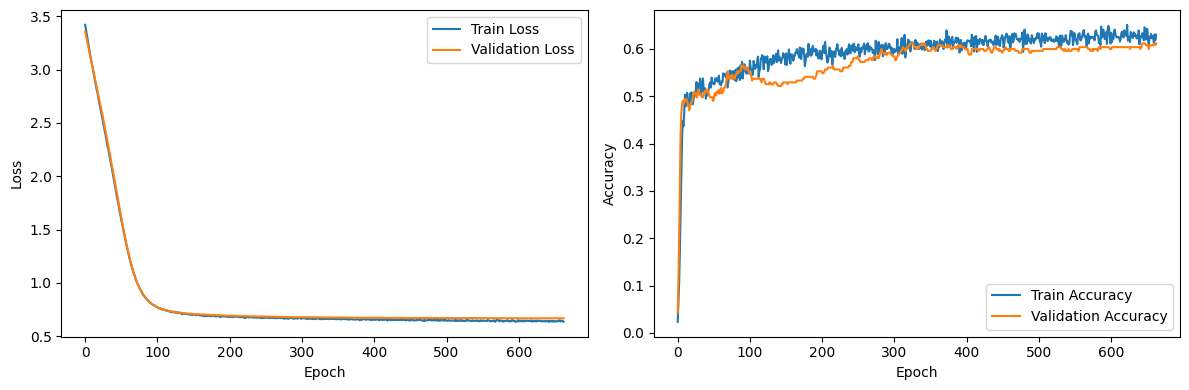


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9892, Val Loss: 2.9257, Train Acc: 0.4791, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.5752, Val Loss: 2.5103, Train Acc: 0.4964, Val Acc: 0.5085
Epoch: 030, Train Loss: 2.1433, Val Loss: 2.0956, Train Acc: 0.5082, Val Acc: 0.5127
Epoch: 040, Train Loss: 1.7183, Val Loss: 1.6816, Train Acc: 0.5036, Val Acc: 0.5127
Epoch: 050, Train Loss: 1.3435, Val Loss: 1.3171, Train Acc: 0.5218, Val Acc: 0.5212
Epoch: 060, Train Loss: 1.0721, Val Loss: 1.0584, Train Acc: 0.5209, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.9088, Val Loss: 0.9082, Train Acc: 0.5481, Val Acc: 0.5593
Epoch: 080, Train Loss: 0.8302, Val Loss: 0.8307, Train Acc: 0.5789, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.7815, Val Loss: 0.7923, Train Acc: 0.5744, Val Acc: 0.5169
Epoch: 100, Train Loss: 0.7518, Val Loss: 0.7716, Train Acc: 0.5853, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.7312, Val Loss: 0.7594, Tr

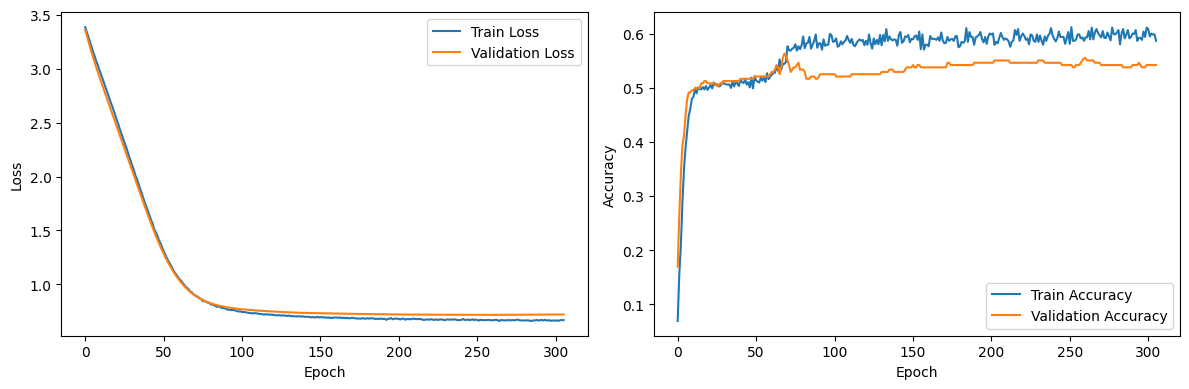


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1357, Val Loss: 3.0506, Train Acc: 0.4803, Val Acc: 0.5550
Epoch: 020, Train Loss: 2.7743, Val Loss: 2.6728, Train Acc: 0.5482, Val Acc: 0.5505
Epoch: 030, Train Loss: 2.4009, Val Loss: 2.2989, Train Acc: 0.5413, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.9899, Val Loss: 1.9124, Train Acc: 0.5482, Val Acc: 0.4954
Epoch: 050, Train Loss: 1.5881, Val Loss: 1.5353, Train Acc: 0.5413, Val Acc: 0.4862
Epoch: 060, Train Loss: 1.2522, Val Loss: 1.2218, Train Acc: 0.5541, Val Acc: 0.4954
Epoch: 070, Train Loss: 1.0208, Val Loss: 1.0101, Train Acc: 0.5492, Val Acc: 0.4862
Epoch: 080, Train Loss: 0.8907, Val Loss: 0.8885, Train Acc: 0.5335, Val Acc: 0.4862
Epoch: 090, Train Loss: 0.8222, Val Loss: 0.8224, Train Acc: 0.5492, Val Acc: 0.4954
Epoch: 100, Train Loss: 0.7799, Val Loss: 0.7861, Train Acc: 0.5512, Val Acc: 0.5092
Epoch: 110, Train Loss: 0.7564, Val Loss: 0.7629, Tr

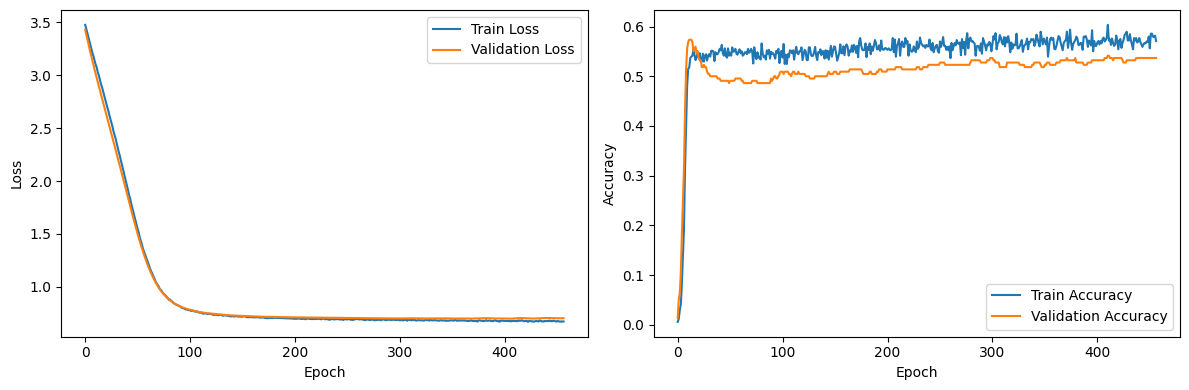


========== Run 9 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1755, Val Loss: 3.1153, Train Acc: 0.1652, Val Acc: 0.1692
Epoch: 020, Train Loss: 2.8066, Val Loss: 2.7436, Train Acc: 0.4932, Val Acc: 0.4812
Epoch: 030, Train Loss: 2.4365, Val Loss: 2.3831, Train Acc: 0.5149, Val Acc: 0.4774
Epoch: 040, Train Loss: 2.0444, Val Loss: 1.9964, Train Acc: 0.5230, Val Acc: 0.5150
Epoch: 050, Train Loss: 1.6419, Val Loss: 1.6020, Train Acc: 0.5407, Val Acc: 0.5301
Epoch: 060, Train Loss: 1.2943, Val Loss: 1.2586, Train Acc: 0.5415, Val Acc: 0.5301
Epoch: 070, Train Loss: 1.0367, Val Loss: 1.0203, Train Acc: 0.5496, Val Acc: 0.5564
Epoch: 080, Train Loss: 0.8948, Val Loss: 0.8848, Train Acc: 0.5471, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.8137, Val Loss: 0.8152, Train Acc: 0.5528, Val Acc: 0.5789
Epoch: 100, Train Loss: 0.7749, Val Loss: 0.7781, Train Acc: 0.5657, Val Acc: 0.5902
Epoch: 110, Train Loss

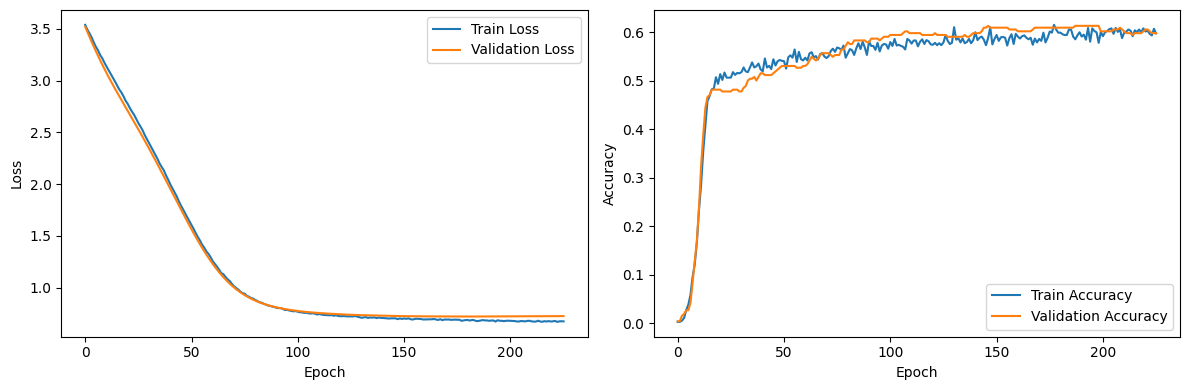


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2122, Val Loss: 3.2274, Train Acc: 0.2869, Val Acc: 0.3765
Epoch: 020, Train Loss: 2.8586, Val Loss: 2.9076, Train Acc: 0.5076, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.5089, Val Loss: 2.5640, Train Acc: 0.4983, Val Acc: 0.5020
Epoch: 040, Train Loss: 2.1462, Val Loss: 2.1770, Train Acc: 0.5210, Val Acc: 0.5137
Epoch: 050, Train Loss: 1.7421, Val Loss: 1.7627, Train Acc: 0.5143, Val Acc: 0.5137
Epoch: 060, Train Loss: 1.3701, Val Loss: 1.3781, Train Acc: 0.5310, Val Acc: 0.5216
Epoch: 070, Train Loss: 1.0909, Val Loss: 1.0924, Train Acc: 0.5260, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.9217, Val Loss: 0.9239, Train Acc: 0.5436, Val Acc: 0.5255
Epoch: 090, Train Loss: 0.8302, Val Loss: 0.8355, Train Acc: 0.5378, Val Acc: 0.5137
Epoch: 100, Train Loss: 0.7804, Val Loss: 0.7883, Train Acc: 0.5621, Val Acc: 0.4941
Epoch: 110, Train Loss: 0.7506, Val Loss: 0.7610, Tr

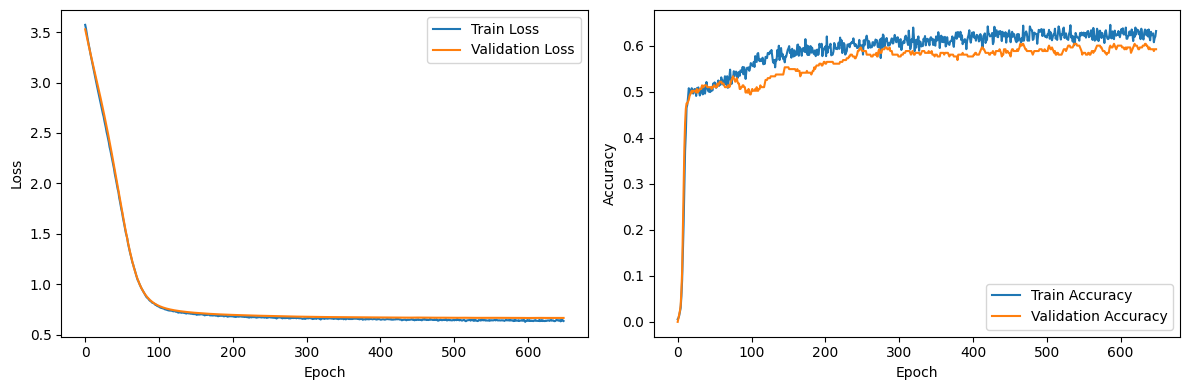


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0720, Val Loss: 3.0260, Train Acc: 0.5526, Val Acc: 0.4831
Epoch: 020, Train Loss: 2.7209, Val Loss: 2.6803, Train Acc: 0.5735, Val Acc: 0.4661
Epoch: 030, Train Loss: 2.3417, Val Loss: 2.3115, Train Acc: 0.5844, Val Acc: 0.4915
Epoch: 040, Train Loss: 1.9340, Val Loss: 1.9145, Train Acc: 0.5826, Val Acc: 0.4831
Epoch: 050, Train Loss: 1.5332, Val Loss: 1.5222, Train Acc: 0.5808, Val Acc: 0.5127
Epoch: 060, Train Loss: 1.1903, Val Loss: 1.1955, Train Acc: 0.5799, Val Acc: 0.5127
Epoch: 070, Train Loss: 0.9795, Val Loss: 0.9794, Train Acc: 0.5862, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.8541, Val Loss: 0.8627, Train Acc: 0.5708, Val Acc: 0.5297
Epoch: 090, Train Loss: 0.7892, Val Loss: 0.8043, Train Acc: 0.5744, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.7547, Val Loss: 0.7750, Train Acc: 0.5762, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.7318, Val Loss: 0.7582, Tr

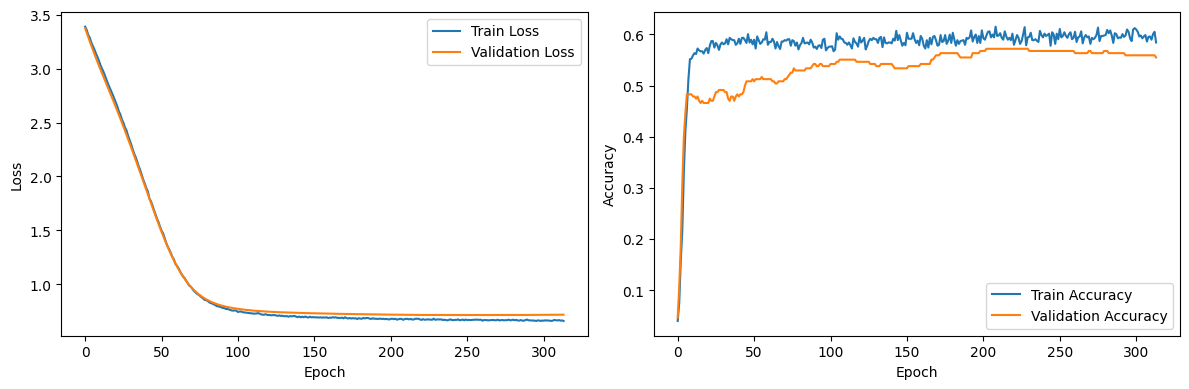


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1871, Val Loss: 3.1336, Train Acc: 0.4498, Val Acc: 0.4404
Epoch: 020, Train Loss: 2.7623, Val Loss: 2.6884, Train Acc: 0.5039, Val Acc: 0.4725
Epoch: 030, Train Loss: 2.3363, Val Loss: 2.2632, Train Acc: 0.5098, Val Acc: 0.4679
Epoch: 040, Train Loss: 1.8961, Val Loss: 1.8492, Train Acc: 0.5049, Val Acc: 0.4587
Epoch: 050, Train Loss: 1.5048, Val Loss: 1.4771, Train Acc: 0.5039, Val Acc: 0.4495
Epoch: 060, Train Loss: 1.1989, Val Loss: 1.1920, Train Acc: 0.5148, Val Acc: 0.4587
Epoch: 070, Train Loss: 1.0014, Val Loss: 1.0044, Train Acc: 0.5285, Val Acc: 0.4725
Epoch: 080, Train Loss: 0.8761, Val Loss: 0.8911, Train Acc: 0.5305, Val Acc: 0.4908
Epoch: 090, Train Loss: 0.8208, Val Loss: 0.8247, Train Acc: 0.5236, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.7772, Val Loss: 0.7854, Train Acc: 0.5591, Val Acc: 0.5275
Epoch: 110, Train Loss: 0.7543, Val Loss: 0.7623, Tr

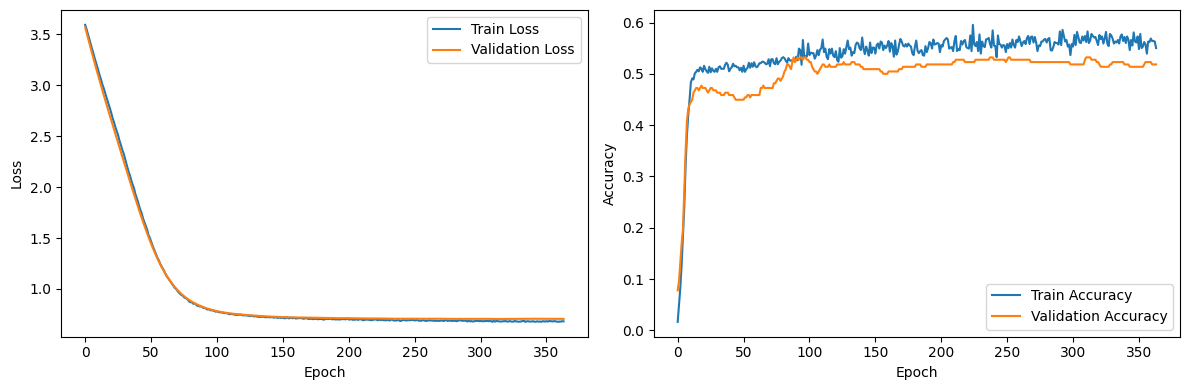


========== Run 10 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1763, Val Loss: 3.1104, Train Acc: 0.3965, Val Acc: 0.4887
Epoch: 020, Train Loss: 2.8019, Val Loss: 2.7216, Train Acc: 0.5310, Val Acc: 0.5075
Epoch: 030, Train Loss: 2.4128, Val Loss: 2.3275, Train Acc: 0.5294, Val Acc: 0.5150
Epoch: 040, Train Loss: 1.9983, Val Loss: 1.9121, Train Acc: 0.5383, Val Acc: 0.5338
Epoch: 050, Train Loss: 1.5851, Val Loss: 1.5074, Train Acc: 0.5415, Val Acc: 0.5414
Epoch: 060, Train Loss: 1.2346, Val Loss: 1.1765, Train Acc: 0.5367, Val Acc: 0.5489
Epoch: 070, Train Loss: 1.0045, Val Loss: 0.9636, Train Acc: 0.5504, Val Acc: 0.5602
Epoch: 080, Train Loss: 0.8742, Val Loss: 0.8488, Train Acc: 0.5673, Val Acc: 0.5902
Epoch: 090, Train Loss: 0.8106, Val Loss: 0.7906, Train Acc: 0.5584, Val Acc: 0.6015
Epoch: 100, Train Loss: 0.7686, Val Loss: 0.7598, Train Acc: 0.5624, Val Acc: 0.6128
Epoch: 110, Train Los

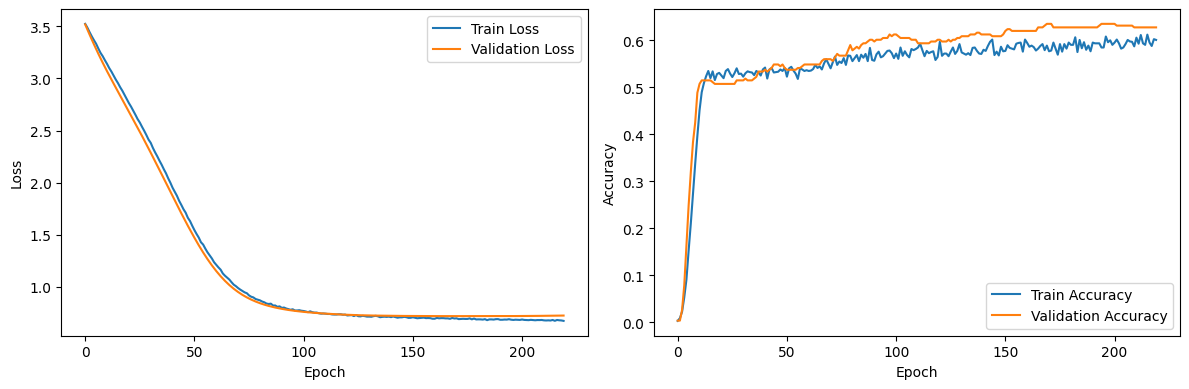


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1326, Val Loss: 3.1001, Train Acc: 0.4857, Val Acc: 0.4941
Epoch: 020, Train Loss: 2.7082, Val Loss: 2.7068, Train Acc: 0.5008, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.2775, Val Loss: 2.2881, Train Acc: 0.5034, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.8395, Val Loss: 1.8529, Train Acc: 0.5101, Val Acc: 0.5059
Epoch: 050, Train Loss: 1.4473, Val Loss: 1.4533, Train Acc: 0.5210, Val Acc: 0.5098
Epoch: 060, Train Loss: 1.1550, Val Loss: 1.1540, Train Acc: 0.5310, Val Acc: 0.5333
Epoch: 070, Train Loss: 0.9673, Val Loss: 0.9676, Train Acc: 0.5319, Val Acc: 0.5255
Epoch: 080, Train Loss: 0.8561, Val Loss: 0.8610, Train Acc: 0.5495, Val Acc: 0.5176
Epoch: 090, Train Loss: 0.7968, Val Loss: 0.8012, Train Acc: 0.5621, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.7592, Val Loss: 0.7662, Train Acc: 0.5696, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.7369, Val Loss: 0.7437, Tr

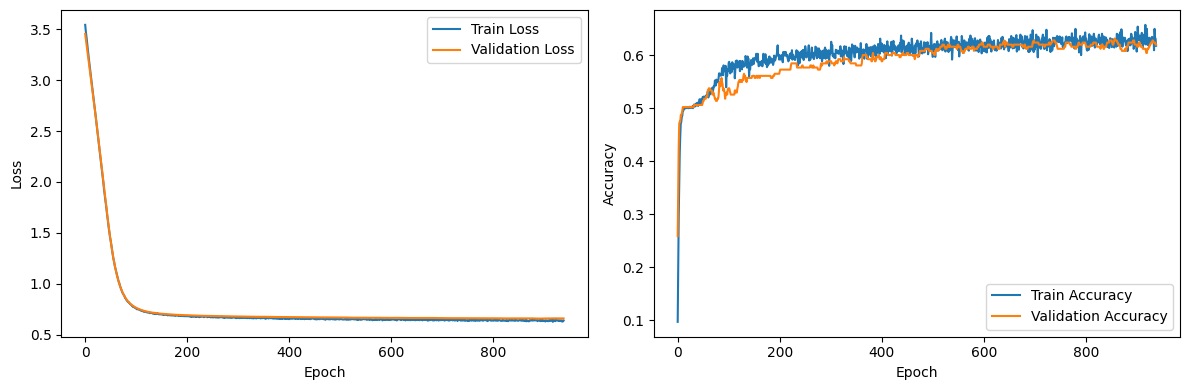


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1096, Val Loss: 3.0823, Train Acc: 0.4610, Val Acc: 0.4873
Epoch: 020, Train Loss: 2.7041, Val Loss: 2.6775, Train Acc: 0.5018, Val Acc: 0.4958
Epoch: 030, Train Loss: 2.3035, Val Loss: 2.2805, Train Acc: 0.4973, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.8964, Val Loss: 1.8724, Train Acc: 0.5000, Val Acc: 0.5212
Epoch: 050, Train Loss: 1.5037, Val Loss: 1.4877, Train Acc: 0.5027, Val Acc: 0.5254
Epoch: 060, Train Loss: 1.1947, Val Loss: 1.1818, Train Acc: 0.5045, Val Acc: 0.5297
Epoch: 070, Train Loss: 0.9967, Val Loss: 0.9818, Train Acc: 0.5082, Val Acc: 0.5212
Epoch: 080, Train Loss: 0.8747, Val Loss: 0.8695, Train Acc: 0.5417, Val Acc: 0.5085
Epoch: 090, Train Loss: 0.8026, Val Loss: 0.8117, Train Acc: 0.5599, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.7645, Val Loss: 0.7827, Train Acc: 0.5926, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.7388, Val Loss: 0.7670, Tr

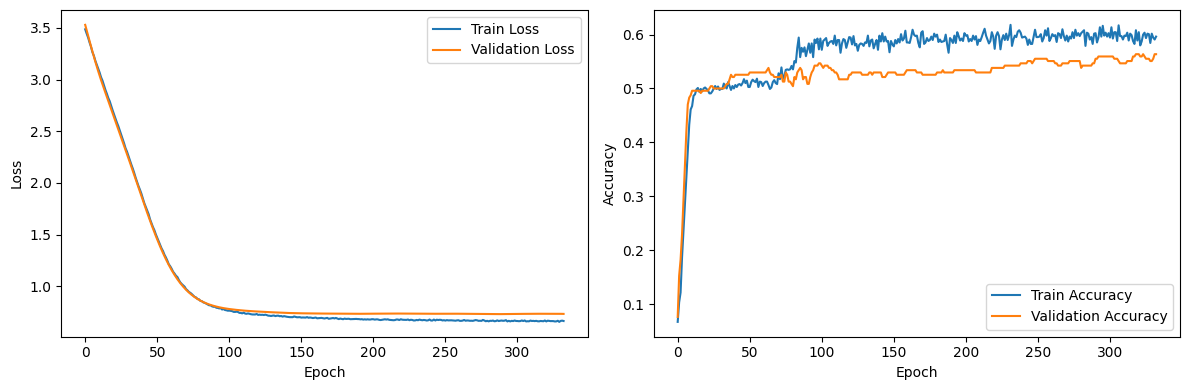


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9387, Val Loss: 2.8332, Train Acc: 0.4970, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.5537, Val Loss: 2.4476, Train Acc: 0.5039, Val Acc: 0.5138
Epoch: 030, Train Loss: 2.1695, Val Loss: 2.0691, Train Acc: 0.5049, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.7761, Val Loss: 1.6914, Train Acc: 0.5039, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.3984, Val Loss: 1.3518, Train Acc: 0.5157, Val Acc: 0.5000
Epoch: 060, Train Loss: 1.1230, Val Loss: 1.0988, Train Acc: 0.5463, Val Acc: 0.4817
Epoch: 070, Train Loss: 0.9468, Val Loss: 0.9443, Train Acc: 0.5581, Val Acc: 0.4862
Epoch: 080, Train Loss: 0.8499, Val Loss: 0.8580, Train Acc: 0.5472, Val Acc: 0.5000
Epoch: 090, Train Loss: 0.7930, Val Loss: 0.8086, Train Acc: 0.5482, Val Acc: 0.4862
Epoch: 100, Train Loss: 0.7682, Val Loss: 0.7797, Train Acc: 0.5354, Val Acc: 0.4862
Epoch: 110, Train Loss: 0.7518, Val Loss: 0.7602, Tr

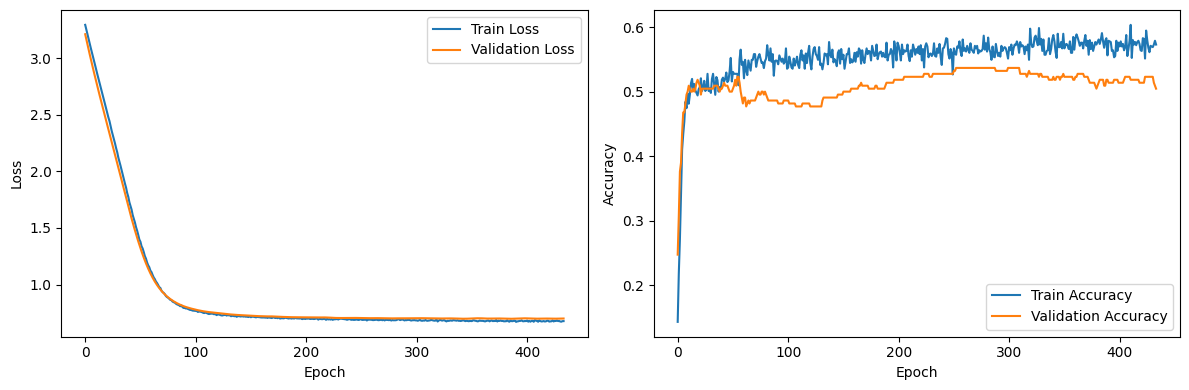


========== Run 11 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1524, Val Loss: 3.0653, Train Acc: 0.4214, Val Acc: 0.4549
Epoch: 020, Train Loss: 2.7776, Val Loss: 2.6973, Train Acc: 0.5520, Val Acc: 0.5038
Epoch: 030, Train Loss: 2.3809, Val Loss: 2.3164, Train Acc: 0.5641, Val Acc: 0.5038
Epoch: 040, Train Loss: 1.9650, Val Loss: 1.9063, Train Acc: 0.5721, Val Acc: 0.5188
Epoch: 050, Train Loss: 1.5612, Val Loss: 1.5044, Train Acc: 0.5673, Val Acc: 0.5150
Epoch: 060, Train Loss: 1.2283, Val Loss: 1.1761, Train Acc: 0.5624, Val Acc: 0.5226
Epoch: 070, Train Loss: 0.9937, Val Loss: 0.9614, Train Acc: 0.5842, Val Acc: 0.5489
Epoch: 080, Train Loss: 0.8652, Val Loss: 0.8457, Train Acc: 0.5987, Val Acc: 0.6015
Epoch: 090, Train Loss: 0.8016, Val Loss: 0.7883, Train Acc: 0.5915, Val Acc: 0.6053
Epoch: 100, Train Loss: 0.7612, Val Loss: 0.7579, Train Acc: 0.5923, Val Acc: 0.5940
Epoch: 110, Train Los

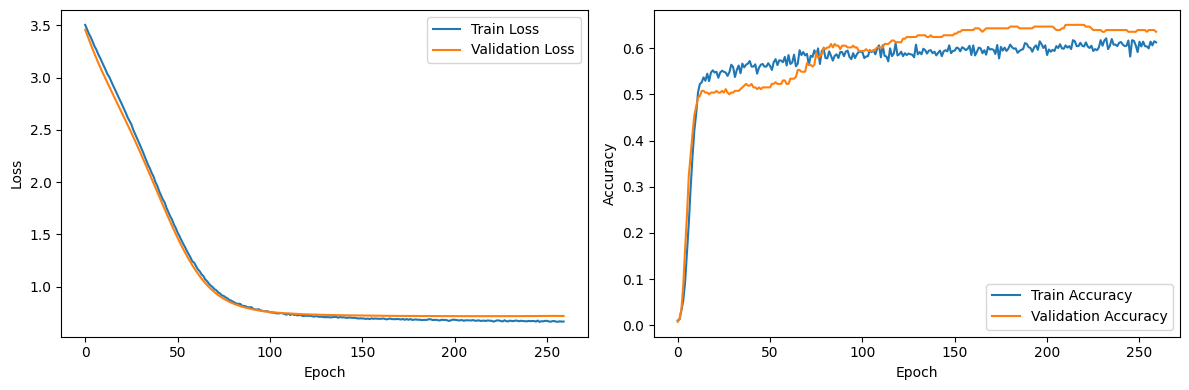


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0784, Val Loss: 3.0412, Train Acc: 0.4539, Val Acc: 0.4824
Epoch: 020, Train Loss: 2.6247, Val Loss: 2.6380, Train Acc: 0.5042, Val Acc: 0.5098
Epoch: 030, Train Loss: 2.2070, Val Loss: 2.2232, Train Acc: 0.5134, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.7954, Val Loss: 1.8030, Train Acc: 0.5336, Val Acc: 0.5216
Epoch: 050, Train Loss: 1.4181, Val Loss: 1.4214, Train Acc: 0.5277, Val Acc: 0.5176
Epoch: 060, Train Loss: 1.1364, Val Loss: 1.1335, Train Acc: 0.5403, Val Acc: 0.5216
Epoch: 070, Train Loss: 0.9555, Val Loss: 0.9545, Train Acc: 0.5579, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.8553, Val Loss: 0.8543, Train Acc: 0.5654, Val Acc: 0.5294
Epoch: 090, Train Loss: 0.7944, Val Loss: 0.7990, Train Acc: 0.5856, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.7655, Val Loss: 0.7665, Train Acc: 0.5822, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.7355, Val Loss: 0.7454, Tr

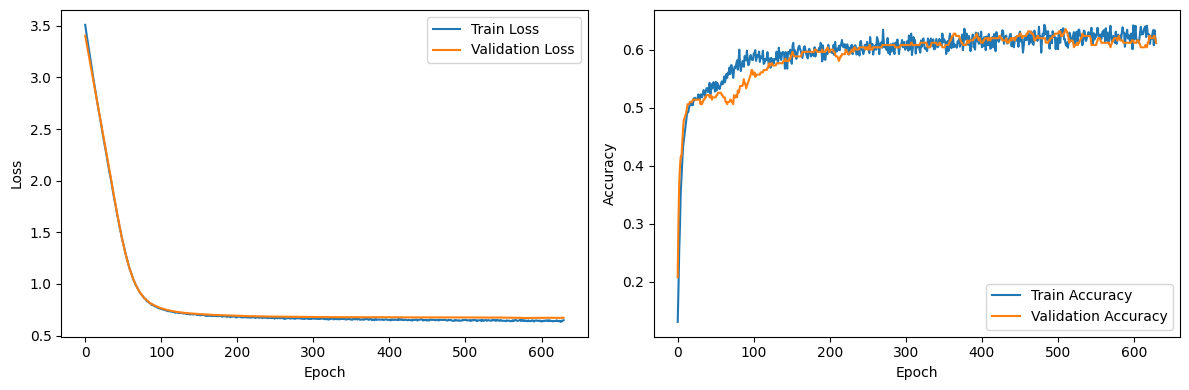


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0269, Val Loss: 2.9581, Train Acc: 0.5136, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.6224, Val Loss: 2.5502, Train Acc: 0.5363, Val Acc: 0.5042
Epoch: 030, Train Loss: 2.1971, Val Loss: 2.1375, Train Acc: 0.5472, Val Acc: 0.5169
Epoch: 040, Train Loss: 1.7677, Val Loss: 1.7223, Train Acc: 0.5581, Val Acc: 0.5466
Epoch: 050, Train Loss: 1.3812, Val Loss: 1.3515, Train Acc: 0.5672, Val Acc: 0.5593
Epoch: 060, Train Loss: 1.0954, Val Loss: 1.0806, Train Acc: 0.5644, Val Acc: 0.5424
Epoch: 070, Train Loss: 0.9251, Val Loss: 0.9204, Train Acc: 0.5608, Val Acc: 0.5212
Epoch: 080, Train Loss: 0.8288, Val Loss: 0.8358, Train Acc: 0.5590, Val Acc: 0.5381
Epoch: 090, Train Loss: 0.7787, Val Loss: 0.7928, Train Acc: 0.5653, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.7459, Val Loss: 0.7698, Train Acc: 0.5771, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.7256, Val Loss: 0.7558, Tr

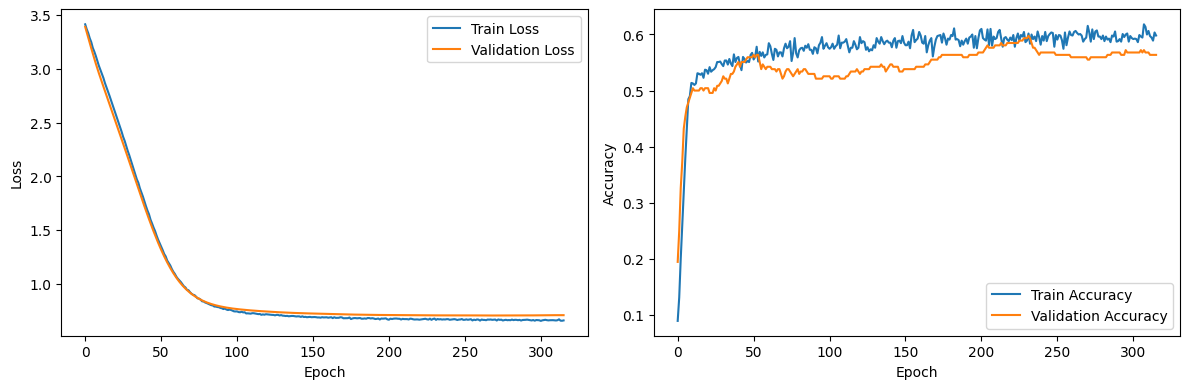


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2177, Val Loss: 3.1409, Train Acc: 0.1752, Val Acc: 0.2294
Epoch: 020, Train Loss: 2.8276, Val Loss: 2.7220, Train Acc: 0.4872, Val Acc: 0.4862
Epoch: 030, Train Loss: 2.4336, Val Loss: 2.3184, Train Acc: 0.5354, Val Acc: 0.4954
Epoch: 040, Train Loss: 2.0077, Val Loss: 1.9086, Train Acc: 0.5128, Val Acc: 0.4954
Epoch: 050, Train Loss: 1.5909, Val Loss: 1.5189, Train Acc: 0.5433, Val Acc: 0.4908
Epoch: 060, Train Loss: 1.2441, Val Loss: 1.2049, Train Acc: 0.5738, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.0099, Val Loss: 1.0010, Train Acc: 0.5571, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.8858, Val Loss: 0.8871, Train Acc: 0.5423, Val Acc: 0.5275
Epoch: 090, Train Loss: 0.8172, Val Loss: 0.8250, Train Acc: 0.5443, Val Acc: 0.5275
Epoch: 100, Train Loss: 0.7790, Val Loss: 0.7902, Train Acc: 0.5610, Val Acc: 0.5183
Epoch: 110, Train Loss: 0.7553, Val Loss: 0.7682, Tr

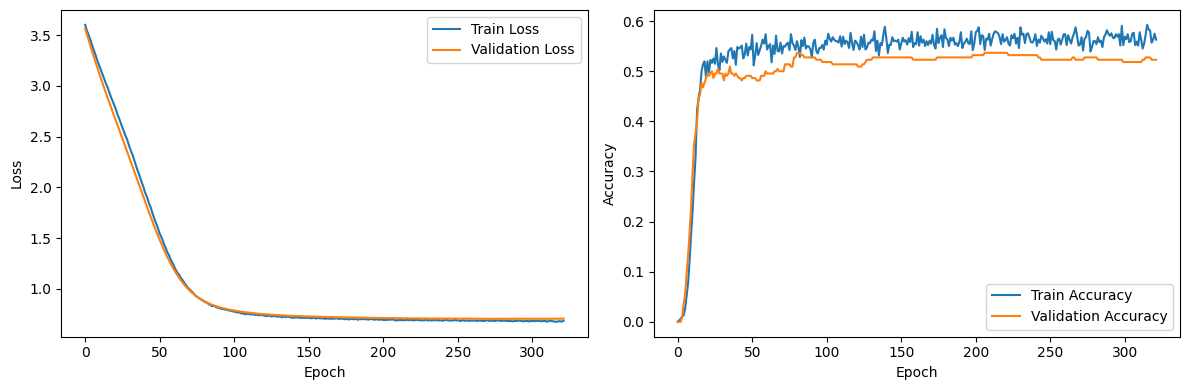


========== Run 12 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2358, Val Loss: 3.1391, Train Acc: 0.2869, Val Acc: 0.3835
Epoch: 020, Train Loss: 2.9009, Val Loss: 2.7994, Train Acc: 0.5085, Val Acc: 0.5150
Epoch: 030, Train Loss: 2.5420, Val Loss: 2.4542, Train Acc: 0.5093, Val Acc: 0.5226
Epoch: 040, Train Loss: 2.1534, Val Loss: 2.0719, Train Acc: 0.5310, Val Acc: 0.5188
Epoch: 050, Train Loss: 1.7475, Val Loss: 1.6707, Train Acc: 0.5254, Val Acc: 0.5301
Epoch: 060, Train Loss: 1.3752, Val Loss: 1.3134, Train Acc: 0.5576, Val Acc: 0.5526
Epoch: 070, Train Loss: 1.1037, Val Loss: 1.0568, Train Acc: 0.5512, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.9418, Val Loss: 0.9030, Train Acc: 0.5753, Val Acc: 0.6015
Epoch: 090, Train Loss: 0.8363, Val Loss: 0.8189, Train Acc: 0.5979, Val Acc: 0.6241
Epoch: 100, Train Loss: 0.7846, Val Loss: 0.7734, Train Acc: 0.5794, Val Acc: 0.6165
Epoch: 110, Train Los

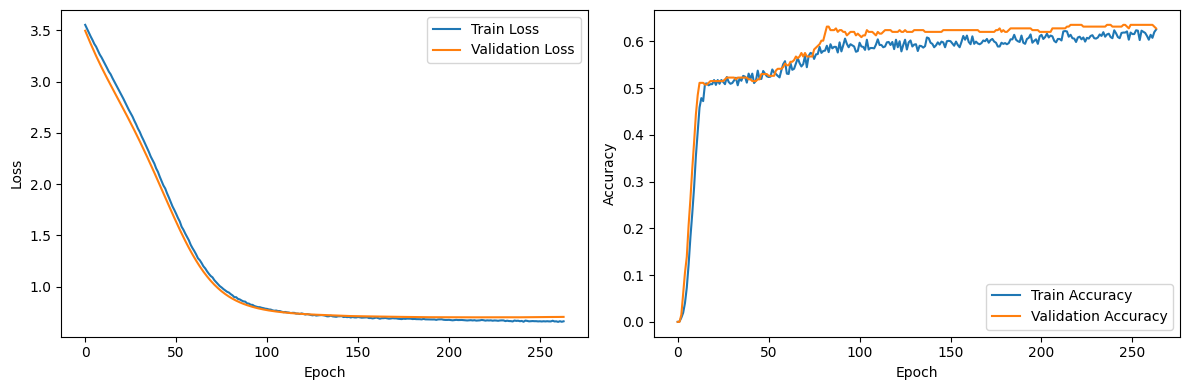


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1927, Val Loss: 3.1998, Train Acc: 0.3171, Val Acc: 0.3725
Epoch: 020, Train Loss: 2.8368, Val Loss: 2.8743, Train Acc: 0.5159, Val Acc: 0.5333
Epoch: 030, Train Loss: 2.4706, Val Loss: 2.5175, Train Acc: 0.5310, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.0865, Val Loss: 2.1237, Train Acc: 0.5260, Val Acc: 0.5490
Epoch: 050, Train Loss: 1.6863, Val Loss: 1.7138, Train Acc: 0.5336, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.3257, Val Loss: 1.3408, Train Acc: 0.5344, Val Acc: 0.5451
Epoch: 070, Train Loss: 1.0626, Val Loss: 1.0678, Train Acc: 0.5453, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.9086, Val Loss: 0.9072, Train Acc: 0.5537, Val Acc: 0.5412
Epoch: 090, Train Loss: 0.8205, Val Loss: 0.8218, Train Acc: 0.5688, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.7759, Val Loss: 0.7758, Train Acc: 0.5747, Val Acc: 0.5412
Epoch: 110, Train Loss: 0.7466, Val Loss: 0.7489, Tr

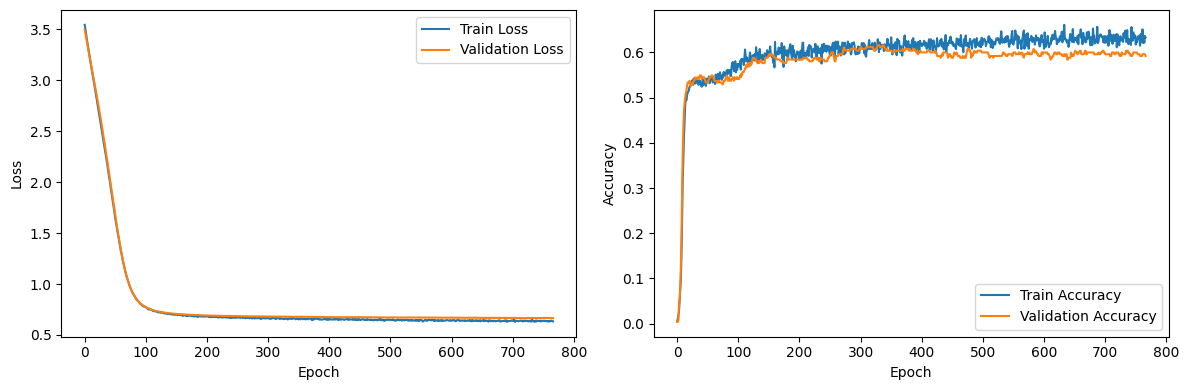


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1787, Val Loss: 3.1277, Train Acc: 0.3666, Val Acc: 0.3771
Epoch: 020, Train Loss: 2.8168, Val Loss: 2.7739, Train Acc: 0.5227, Val Acc: 0.5085
Epoch: 030, Train Loss: 2.4316, Val Loss: 2.3976, Train Acc: 0.5372, Val Acc: 0.5000
Epoch: 040, Train Loss: 2.0152, Val Loss: 1.9890, Train Acc: 0.5463, Val Acc: 0.5212
Epoch: 050, Train Loss: 1.5972, Val Loss: 1.5798, Train Acc: 0.5517, Val Acc: 0.5127
Epoch: 060, Train Loss: 1.2552, Val Loss: 1.2351, Train Acc: 0.5626, Val Acc: 0.5212
Epoch: 070, Train Loss: 1.0169, Val Loss: 1.0057, Train Acc: 0.5662, Val Acc: 0.5508
Epoch: 080, Train Loss: 0.8879, Val Loss: 0.8793, Train Acc: 0.5662, Val Acc: 0.5678
Epoch: 090, Train Loss: 0.8131, Val Loss: 0.8138, Train Acc: 0.5662, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.7737, Val Loss: 0.7785, Train Acc: 0.5753, Val Acc: 0.5424
Epoch: 110, Train Loss: 0.7459, Val Loss: 0.7581, Tr

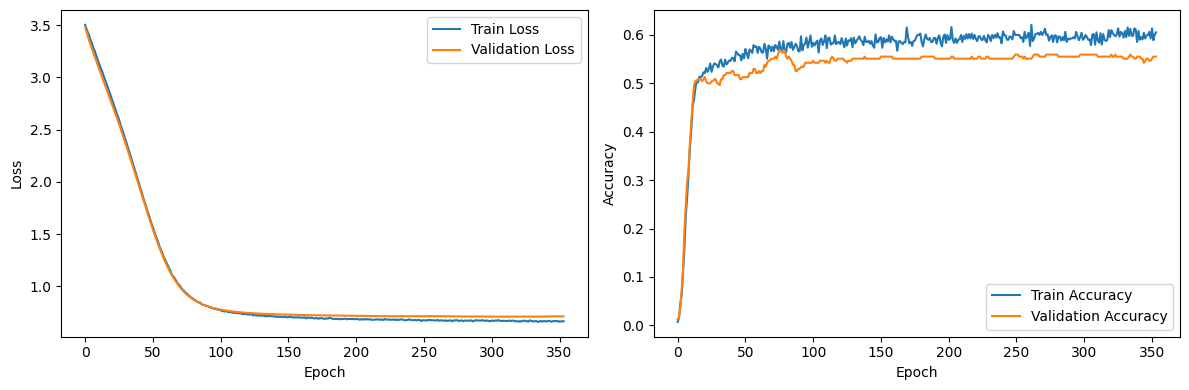


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1718, Val Loss: 3.0975, Train Acc: 0.3465, Val Acc: 0.4404
Epoch: 020, Train Loss: 2.8199, Val Loss: 2.7163, Train Acc: 0.5256, Val Acc: 0.5275
Epoch: 030, Train Loss: 2.4662, Val Loss: 2.3499, Train Acc: 0.5404, Val Acc: 0.5688
Epoch: 040, Train Loss: 2.0877, Val Loss: 1.9710, Train Acc: 0.5413, Val Acc: 0.5321
Epoch: 050, Train Loss: 1.6846, Val Loss: 1.5966, Train Acc: 0.5374, Val Acc: 0.5229
Epoch: 060, Train Loss: 1.3477, Val Loss: 1.2744, Train Acc: 0.5404, Val Acc: 0.5321
Epoch: 070, Train Loss: 1.0977, Val Loss: 1.0443, Train Acc: 0.5285, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.9390, Val Loss: 0.9065, Train Acc: 0.5256, Val Acc: 0.5413
Epoch: 090, Train Loss: 0.8416, Val Loss: 0.8314, Train Acc: 0.5364, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.7977, Val Loss: 0.7910, Train Acc: 0.5374, Val Acc: 0.5092
Epoch: 110, Train Loss: 0.7673, Val Loss: 0.7668, Tr

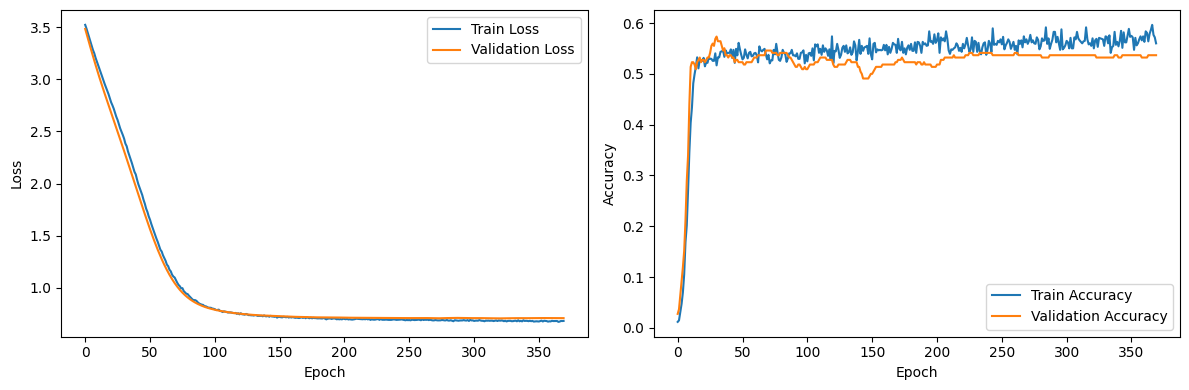


========== Run 13 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1365, Val Loss: 3.0615, Train Acc: 0.4577, Val Acc: 0.4850
Epoch: 020, Train Loss: 2.7753, Val Loss: 2.6858, Train Acc: 0.5141, Val Acc: 0.5188
Epoch: 030, Train Loss: 2.4115, Val Loss: 2.3299, Train Acc: 0.5205, Val Acc: 0.5150
Epoch: 040, Train Loss: 2.0243, Val Loss: 1.9494, Train Acc: 0.5270, Val Acc: 0.5301
Epoch: 050, Train Loss: 1.6318, Val Loss: 1.5690, Train Acc: 0.5334, Val Acc: 0.5526
Epoch: 060, Train Loss: 1.2975, Val Loss: 1.2456, Train Acc: 0.5383, Val Acc: 0.5677
Epoch: 070, Train Loss: 1.0561, Val Loss: 1.0212, Train Acc: 0.5479, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.9114, Val Loss: 0.8923, Train Acc: 0.5528, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.8311, Val Loss: 0.8266, Train Acc: 0.5641, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.7823, Val Loss: 0.7925, Train Acc: 0.5753, Val Acc: 0.5752
Epoch: 110, Train Los

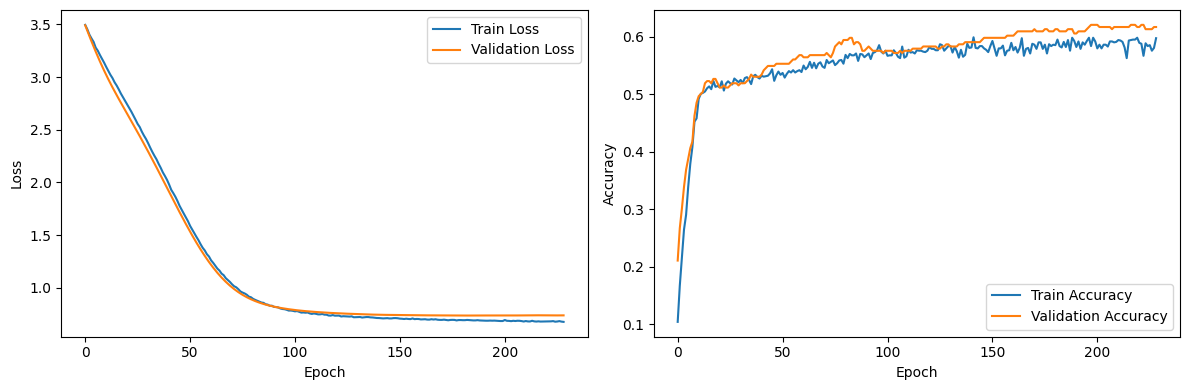


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1397, Val Loss: 3.1618, Train Acc: 0.2961, Val Acc: 0.3804
Epoch: 020, Train Loss: 2.7515, Val Loss: 2.7889, Train Acc: 0.5394, Val Acc: 0.5373
Epoch: 030, Train Loss: 2.3508, Val Loss: 2.3861, Train Acc: 0.5470, Val Acc: 0.5490
Epoch: 040, Train Loss: 1.9283, Val Loss: 1.9536, Train Acc: 0.5654, Val Acc: 0.5686
Epoch: 050, Train Loss: 1.5208, Val Loss: 1.5294, Train Acc: 0.5663, Val Acc: 0.5843
Epoch: 060, Train Loss: 1.1833, Val Loss: 1.1847, Train Acc: 0.5789, Val Acc: 0.6157
Epoch: 070, Train Loss: 0.9643, Val Loss: 0.9644, Train Acc: 0.5520, Val Acc: 0.5804
Epoch: 080, Train Loss: 0.8415, Val Loss: 0.8457, Train Acc: 0.5906, Val Acc: 0.5804
Epoch: 090, Train Loss: 0.7858, Val Loss: 0.7841, Train Acc: 0.5705, Val Acc: 0.5765
Epoch: 100, Train Loss: 0.7505, Val Loss: 0.7510, Train Acc: 0.5822, Val Acc: 0.5686
Epoch: 110, Train Loss: 0.7295, Val Loss: 0.7314, Tr

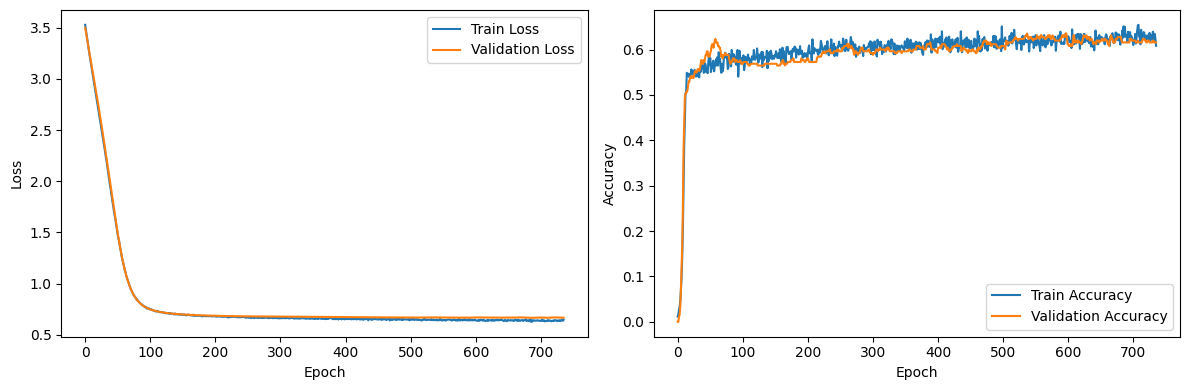


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9754, Val Loss: 2.9262, Train Acc: 0.5127, Val Acc: 0.4619
Epoch: 020, Train Loss: 2.5721, Val Loss: 2.5167, Train Acc: 0.5227, Val Acc: 0.4788
Epoch: 030, Train Loss: 2.1590, Val Loss: 2.1087, Train Acc: 0.5535, Val Acc: 0.4746
Epoch: 040, Train Loss: 1.7543, Val Loss: 1.7032, Train Acc: 0.5599, Val Acc: 0.4915
Epoch: 050, Train Loss: 1.3689, Val Loss: 1.3395, Train Acc: 0.5708, Val Acc: 0.4958
Epoch: 060, Train Loss: 1.0866, Val Loss: 1.0713, Train Acc: 0.5744, Val Acc: 0.5339
Epoch: 070, Train Loss: 0.9168, Val Loss: 0.9126, Train Acc: 0.5817, Val Acc: 0.5297
Epoch: 080, Train Loss: 0.8245, Val Loss: 0.8307, Train Acc: 0.5953, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.7761, Val Loss: 0.7892, Train Acc: 0.5771, Val Acc: 0.5381
Epoch: 100, Train Loss: 0.7441, Val Loss: 0.7662, Train Acc: 0.5717, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.7267, Val Loss: 0.7520, Tr

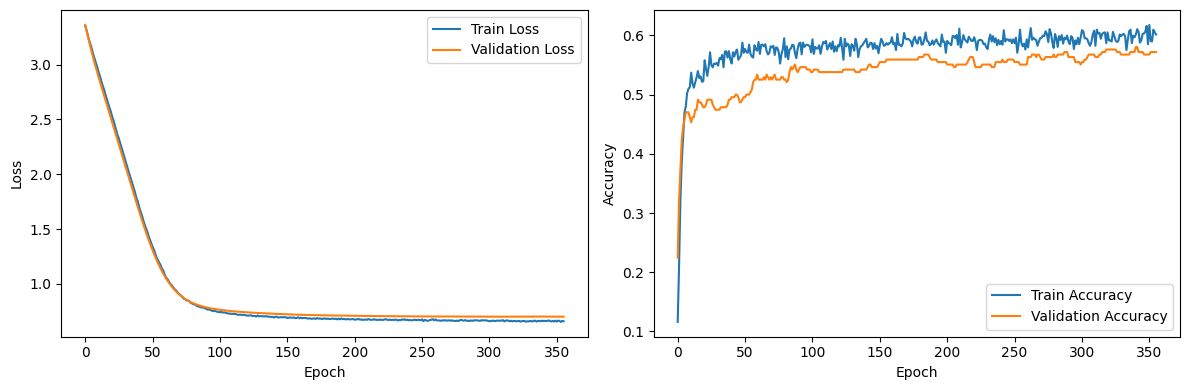


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1186, Val Loss: 3.0168, Train Acc: 0.2480, Val Acc: 0.2936
Epoch: 020, Train Loss: 2.7551, Val Loss: 2.6501, Train Acc: 0.5197, Val Acc: 0.4908
Epoch: 030, Train Loss: 2.3672, Val Loss: 2.2769, Train Acc: 0.5512, Val Acc: 0.4679
Epoch: 040, Train Loss: 1.9711, Val Loss: 1.8949, Train Acc: 0.5453, Val Acc: 0.4725
Epoch: 050, Train Loss: 1.5900, Val Loss: 1.5324, Train Acc: 0.5315, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.2709, Val Loss: 1.2337, Train Acc: 0.5443, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.0430, Val Loss: 1.0287, Train Acc: 0.5433, Val Acc: 0.4862
Epoch: 080, Train Loss: 0.9128, Val Loss: 0.9073, Train Acc: 0.5433, Val Acc: 0.4862
Epoch: 090, Train Loss: 0.8332, Val Loss: 0.8377, Train Acc: 0.5453, Val Acc: 0.4862
Epoch: 100, Train Loss: 0.7878, Val Loss: 0.7953, Train Acc: 0.5551, Val Acc: 0.5092
Epoch: 110, Train Loss: 0.7578, Val Loss: 0.7691, Tr

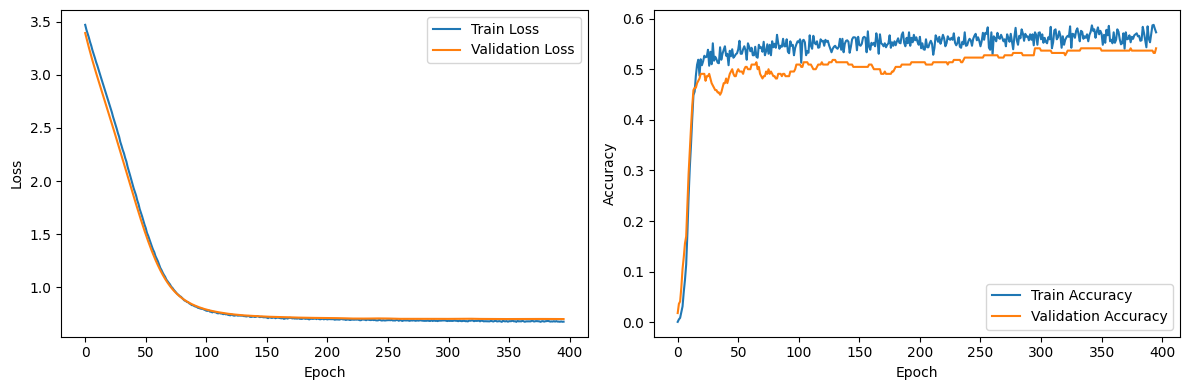


========== Run 14 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9626, Val Loss: 2.8624, Train Acc: 0.5052, Val Acc: 0.5263
Epoch: 020, Train Loss: 2.5140, Val Loss: 2.4198, Train Acc: 0.5560, Val Acc: 0.5451
Epoch: 030, Train Loss: 2.0652, Val Loss: 1.9852, Train Acc: 0.5858, Val Acc: 0.5752
Epoch: 040, Train Loss: 1.6379, Val Loss: 1.5656, Train Acc: 0.5729, Val Acc: 0.5639
Epoch: 050, Train Loss: 1.2667, Val Loss: 1.2174, Train Acc: 0.5947, Val Acc: 0.5714
Epoch: 060, Train Loss: 1.0230, Val Loss: 0.9864, Train Acc: 0.6019, Val Acc: 0.5977
Epoch: 070, Train Loss: 0.8820, Val Loss: 0.8599, Train Acc: 0.5866, Val Acc: 0.6241
Epoch: 080, Train Loss: 0.8009, Val Loss: 0.7965, Train Acc: 0.6052, Val Acc: 0.6278
Epoch: 090, Train Loss: 0.7601, Val Loss: 0.7649, Train Acc: 0.5898, Val Acc: 0.6391
Epoch: 100, Train Loss: 0.7356, Val Loss: 0.7488, Train Acc: 0.5898, Val Acc: 0.6429
Epoch: 110, Train Los

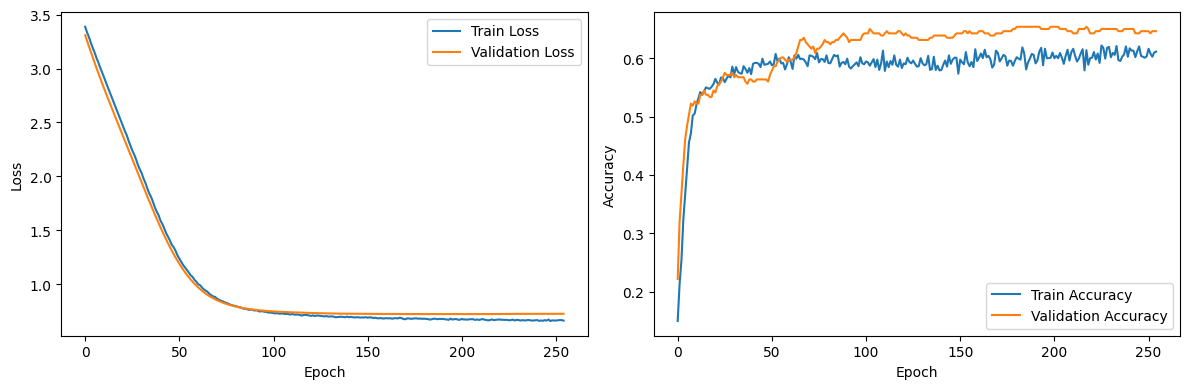


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1343, Val Loss: 3.1260, Train Acc: 0.3951, Val Acc: 0.4275
Epoch: 020, Train Loss: 2.7293, Val Loss: 2.7560, Train Acc: 0.5378, Val Acc: 0.5333
Epoch: 030, Train Loss: 2.3413, Val Loss: 2.3668, Train Acc: 0.5478, Val Acc: 0.5451
Epoch: 040, Train Loss: 1.9235, Val Loss: 1.9555, Train Acc: 0.5445, Val Acc: 0.5686
Epoch: 050, Train Loss: 1.5373, Val Loss: 1.5557, Train Acc: 0.5604, Val Acc: 0.5647
Epoch: 060, Train Loss: 1.2217, Val Loss: 1.2251, Train Acc: 0.5570, Val Acc: 0.5608
Epoch: 070, Train Loss: 0.9981, Val Loss: 1.0037, Train Acc: 0.5562, Val Acc: 0.5647
Epoch: 080, Train Loss: 0.8744, Val Loss: 0.8784, Train Acc: 0.5696, Val Acc: 0.5569
Epoch: 090, Train Loss: 0.7982, Val Loss: 0.8112, Train Acc: 0.5738, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.7649, Val Loss: 0.7738, Train Acc: 0.5940, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.7378, Val Loss: 0.7510, Tr

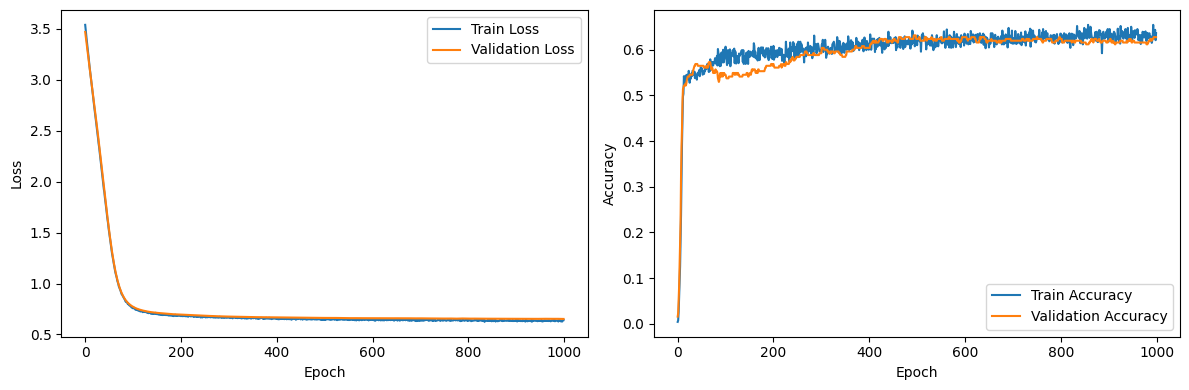


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0521, Val Loss: 2.9825, Train Acc: 0.5281, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.6382, Val Loss: 2.5828, Train Acc: 0.5717, Val Acc: 0.4958
Epoch: 030, Train Loss: 2.2201, Val Loss: 2.1738, Train Acc: 0.5699, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.7827, Val Loss: 1.7599, Train Acc: 0.5735, Val Acc: 0.5042
Epoch: 050, Train Loss: 1.3897, Val Loss: 1.3843, Train Acc: 0.5753, Val Acc: 0.4873
Epoch: 060, Train Loss: 1.1062, Val Loss: 1.1057, Train Acc: 0.5808, Val Acc: 0.4831
Epoch: 070, Train Loss: 0.9226, Val Loss: 0.9383, Train Acc: 0.5880, Val Acc: 0.4831
Epoch: 080, Train Loss: 0.8302, Val Loss: 0.8477, Train Acc: 0.5735, Val Acc: 0.4915
Epoch: 090, Train Loss: 0.7740, Val Loss: 0.7985, Train Acc: 0.5871, Val Acc: 0.5127
Epoch: 100, Train Loss: 0.7445, Val Loss: 0.7704, Train Acc: 0.5808, Val Acc: 0.5212
Epoch: 110, Train Loss: 0.7262, Val Loss: 0.7534, Tr

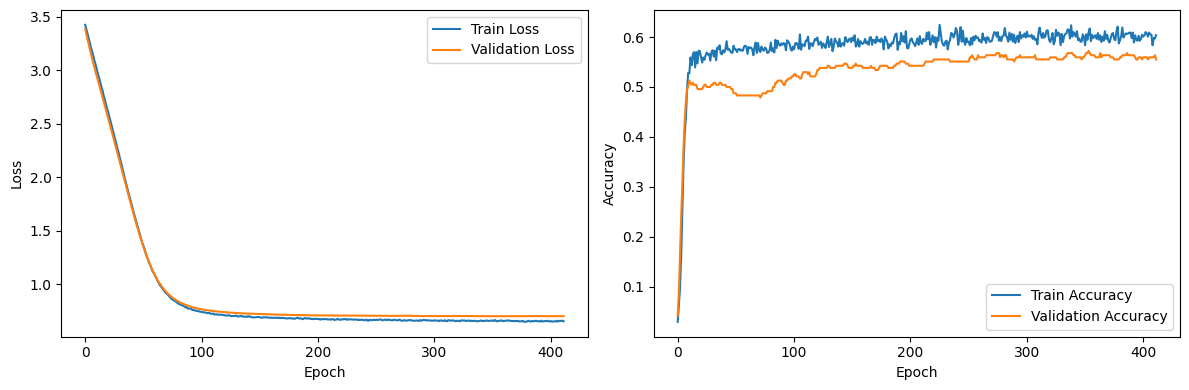


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0961, Val Loss: 3.0207, Train Acc: 0.4754, Val Acc: 0.4954
Epoch: 020, Train Loss: 2.6715, Val Loss: 2.5876, Train Acc: 0.5108, Val Acc: 0.4908
Epoch: 030, Train Loss: 2.2449, Val Loss: 2.1657, Train Acc: 0.5128, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.8216, Val Loss: 1.7600, Train Acc: 0.5217, Val Acc: 0.5138
Epoch: 050, Train Loss: 1.4454, Val Loss: 1.4083, Train Acc: 0.5276, Val Acc: 0.5183
Epoch: 060, Train Loss: 1.1681, Val Loss: 1.1462, Train Acc: 0.5197, Val Acc: 0.4954
Epoch: 070, Train Loss: 0.9821, Val Loss: 0.9774, Train Acc: 0.5325, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.8787, Val Loss: 0.8786, Train Acc: 0.5246, Val Acc: 0.4908
Epoch: 090, Train Loss: 0.8169, Val Loss: 0.8224, Train Acc: 0.5364, Val Acc: 0.4908
Epoch: 100, Train Loss: 0.7821, Val Loss: 0.7898, Train Acc: 0.5295, Val Acc: 0.4725
Epoch: 110, Train Loss: 0.7569, Val Loss: 0.7699, Tr

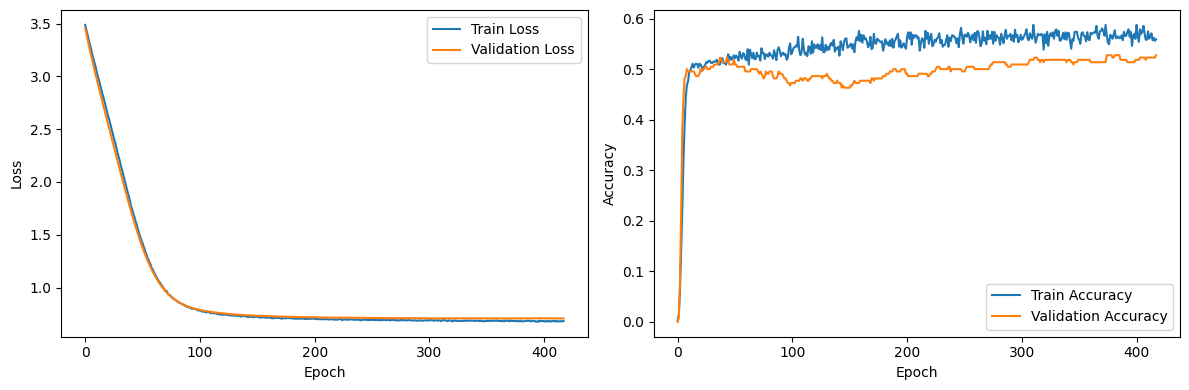


========== Final Summary ==========

Year: 2019
  Avg Test Accuracy: 0.6220 ± 0.0163
  Avg Test F1 Score: 0.6216 ± 0.0162
 Train Accuracy: 0.6010 ± 0.0118
Year: 2020
  Avg Test Accuracy: 0.5603 ± 0.0096
  Avg Test F1 Score: 0.5602 ± 0.0096
 Train Accuracy: 0.6246 ± 0.0127
Year: 2021
  Avg Test Accuracy: 0.5410 ± 0.0085
  Avg Test F1 Score: 0.5408 ± 0.0085
 Train Accuracy: 0.5973 ± 0.0076
Year: 2022
  Avg Test Accuracy: 0.5498 ± 0.0114
  Avg Test F1 Score: 0.5486 ± 0.0117
 Train Accuracy: 0.5692 ± 0.0088


In [6]:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022]
    metric = 'revenue'

    # To store results for each year across 10 runs
    aggregate_results = {year: {'acc': [], 'f1': [], 'time': [], 'epochs': [], 'best_train_acc': []} for year in years}
    param = {
            "hidden_channels": 64,
            "out_channels": 32,
            "num_heads": 4,
            "lr": 0.0009,
            "weight_decay": 5e-4,
            "epochs": 1000,
            "patience": 50
        }

    #Add optuna code section here
    best_params_per_year = {}
    # for year in years:
    #     print(f"\nRunning Optuna optimization for year {year}...\n")
    
    #     study = optuna.create_study(direction="maximize")
    #     study.optimize(lambda trial: objective(trial, year, metric), n_trials=15)
    
    #     print(f"Best trial for year {year}: {study.best_trial.value}")
    #     print("Best hyperparameters:", study.best_params)

    #     best_params_per_year[year] = study.best_params
    
    for i in range(1, 15):
        print(f"\n========== Run {i} ==========\n")
        for year in years:
            # param = best_params_per_year[year]
            print(f"\nRunning experiment for year {year}...\n")
            results = run_experiment(year, metric, **param)
            # Store individual run metrics
            aggregate_results[year]['acc'].append(results['test_acc'])
            aggregate_results[year]['f1'].append(results['test_f1'])
            aggregate_results[year]['time'].append(results['training_time'])
            aggregate_results[year]['epochs'].append(results['epochs_run'])
            aggregate_results[year]['best_train_acc'].append(results['best_train_acc'])

    print("\n========== Final Summary ==========\n")
    for year in years:
        acc_mean = np.mean(aggregate_results[year]['acc'])
        acc_std = np.std(aggregate_results[year]['acc'])
        f1_mean = np.mean(aggregate_results[year]['f1'])
        f1_std = np.std(aggregate_results[year]['f1'])
        train_acc_mean = np.mean(aggregate_results[year]['best_train_acc'])
        train_acc_std = np.std(aggregate_results[year]['best_train_acc'])

        print(f"Year: {year}")
        print(f"  Avg Test Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
        print(f"  Avg Test F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f" Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")